# 07b · The same campaign question, on real data, Google's geo experiment ⭐ (companion)

**The business decision.** A real advertiser spent **$50,000** on a real ad campaign, in **50 US
geos, for four weeks** (16 Feb – 15 Mar 2015), and left 50 geos dark. This is the worked example
published with Google's geo-experiment methodology (Kerman, Wang & Vaver 2017, the
`matched_markets` library), daily **sales and ad cost per geo**, exactly the panel your own
company's data warehouse holds. The question is the one notebook [07](07_geo_lift_synthetic_control.ipynb)
trained us for: **how much incremental sales did the spend cause, and did it pay for itself?**

### What changes when the data is real

Notebook 07 planted a +12% lift in a simulator and graded synthetic control against it. Here nobody
tells us the truth, that is the whole epistemic situation of applied causal inference. Three things
replace the planted truth:

1. **A randomized benchmark.** The 100 geos were split into treatment and control **at random**
   (in matched pairs, as we'll verify from the data itself). So a design-based estimate, the
   matched-pairs difference-in-differences, is *unbiased by construction*. (Recall 07's
   difference-in-differences: the *change* in the treated group, post minus pre, minus the same
   change in the control group; randomizing which geos are treated makes that difference unbiased
   for the campaign effect, because the two groups can then differ only by the coin flip.) It is
   noisy, but it is
   the closest real data ever gets to a known answer, and we grade the synthetic control against it.
2. **Falsification tests** that need no truth: placebo campaigns on untreated geos (Depth B), a
   fake launch date, and a check the simulator could never give us for free, the campaign *ends*,
   so the estimated effect must **switch off when the money does**.
3. **Real messiness**: missing geo-days, heavy-tailed market sizes (the largest geo out-sells the
   smallest by two-and-a-half orders of magnitude, the exact ratio is printed in §2), and a weekly cycle you can see with the naked eye. Each one bites somewhere below,
   and one of them (market size) breaks a naive estimator in Depth A.

### How this notebook is organised

The same **7-step contract** as every notebook, with step 2's "simulate a ground truth" honestly
replaced by "load real data, and say what can still be validated", plus the anchor depths:

- **Depth A**, the naive estimators on a *single* real market (where they fail for real), and a
  convex-hull failure the pre-fit gate catches
- **Depth B**, placebo inference: pseudo-cell permutation, the scale-free RMSE-ratio, placebo-in-time
- **Depth C**, the dollar decision and its sensitivity to the launch date, the donor pool, and the margin


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import data, estimators as est, policy, plots
from cmp.cache import load_or_run   # fit once, load forever, a live lecture never waits on NUTS
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 1
SPEND = 50.0     # the experiment's actual ad spend, $000s (from the cost column)
MARGIN = 0.35    # assumed gross margin for the profit call, swept in Depth C
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
N_PSEUDO = 60 if FAST else 200
print(f"FAST={FAST}  SC sampling={SC}  pseudo-cells={N_PSEUDO}")

FAST=False  SC sampling={'draws': 1500, 'tune': 1500, 'chains': 4}  pseudo-cells=200


## 2 · Load the real data (what replaces "simulate a ground truth")

`cmp.data.load_google_geo()` fetches the two public CSVs (Apache-2.0, pinned commit; ~230 KB, 
cached under `~/.cache/cmp` after the first call) and returns the long panel: `date, geo, sales,
cost, group`. The **data card**, verified in code below:

| fact | value |
|, |, |
| units | 100 US geos, **numbered by size** (geo 1 = largest, visible in the data) |
| period | 93 days, 2015-01-05 → 2015-04-07, daily |
| design | randomized in **matched pairs**: consecutive size-ranked geos split 1 treated / 1 control |
| treatment | ad campaign in the 50 group-2 geos, 16 Feb – 15 Mar (28 days), **$50,000** total spend |
| cooldown | 23 days *after* the spend stops, a free falsification window |
| blemishes | 75 of 9,300 geo-days missing at source (small geos, mostly pre-period), we interpolate and disclose |

Two working conventions. **(a)** We analyse sales in **$000s**, same numerical scale the fitters
were built for: SLSQP's default convergence tolerances are calibrated for objective values of
order 1–10³, and raw-dollar magnitudes let the optimizer declare convergence while the weights
are still moving, a silent misconvergence that bit this project once. **(b)** The treated unit is the **test cell**: the *mean* daily sales per treated
geo. The mean (not the sum) keeps the treated series inside the donors' range, a sum of 50 geos
could never be a convex combination of single geos (the synthetic counterfactual is only ever a
weighted average of the donor geos, so it can never rise above the biggest donor or fall below the
smallest, the treated series must sit *inside* the donors' range, their 'convex hull'), and Depth A shows what happens when a series
escapes the donor hull.

Eyeball the panel below before any model: every geo rides the same weekly cycle (the shared
factors of 07, no longer a modelling assumption but a visible fact), and the treated cell visibly
jumps *inside the campaign window only*.

100 geos (50 treated / 50 control) · 93 days · campaign days 42–69 (28 days) · cooldown 23 days
interpolated geo-days: 75/9300 (0.8%), small geos, mostly pre-period
ad spend: $0 before launch (no anticipation), $50,000 inside the window, $0 after, the design is clean
geo sizes are heavy-tailed: largest $6,728/day vs smallest $18/day (~369x)


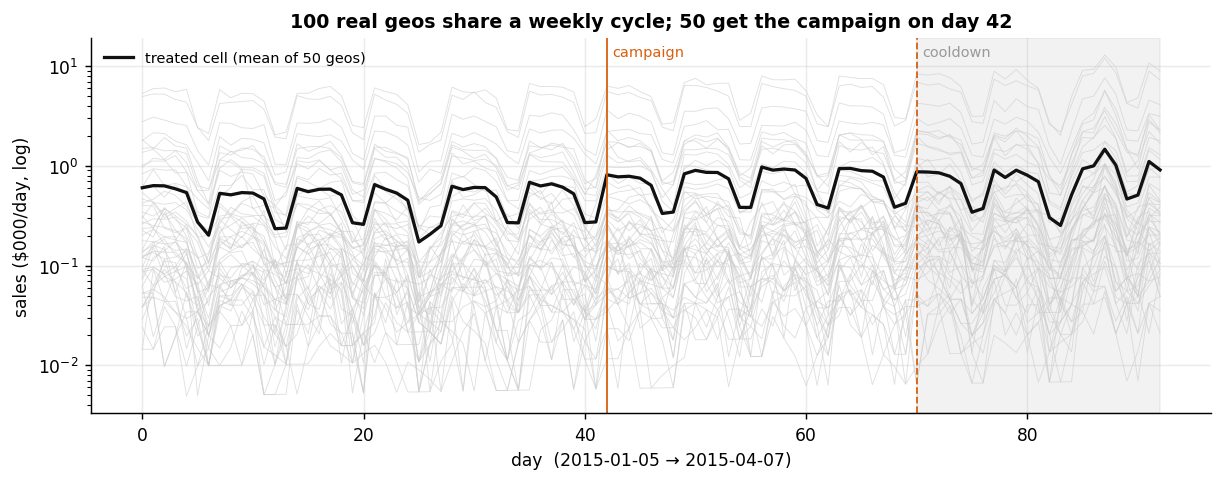

In [2]:
geo_df = data.load_google_geo()                       # date, geo, sales ($), cost ($), group
raw_panel = geo_df.pivot(index="date", columns="geo", values="sales")
n_missing = int(raw_panel.isna().sum().sum())
panel = raw_panel.interpolate(limit_direction="both") / 1000.0        # $000s per geo per day
cost = geo_df.pivot(index="date", columns="geo", values="cost").fillna(0.0)
group = geo_df.drop_duplicates("geo").set_index("geo")["group"]
treated_geos = [g for g in panel.columns if group[g] == 2]
control_geos = [g for g in panel.columns if group[g] == 1]
dates = panel.index
launch = int((dates < "2015-02-16").sum())            # first day with ad spend
end_post = int((dates <= "2015-03-15").sum())         # day after the last campaign day
W = len(dates)
pre, post, cool = slice(0, launch), slice(launch, end_post), slice(end_post, W)
n_treat, n_days = len(treated_geos), end_post - launch
t = np.arange(W)

y_tr = panel[treated_geos].mean(axis=1).values        # the treated CELL (mean $000s/geo/day)
donors = panel[control_geos].values.T                 # (50, W) donor pool

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for g in control_geos:
    ax.plot(t, panel[g], color="#cccccc", lw=0.5, alpha=0.6)
ax.plot(t, y_tr, color="#111", lw=1.8, label="treated cell (mean of 50 geos)")
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax.axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12)
ax.text(launch + 0.5, ax.get_ylim()[1] * 0.92, "campaign", color=plots.ORANGE, fontsize=8)
ax.text(end_post + 0.5, ax.get_ylim()[1] * 0.92, "cooldown", color=plots.GREY, fontsize=8)
ax.set_yscale("log")                                   # heavy-tailed geo sizes: log to see everyone
ax.set_xlabel(f"day  ({dates[0].date()} → {dates[-1].date()})"); ax.set_ylabel("sales ($000/day, log)")
ax.set_title("100 real geos share a weekly cycle; 50 get the campaign on day 42")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()

pre_spend = float(cost.values[:launch].sum()); win_spend = float(cost.values[launch:end_post].sum())
print(f"{len(panel.columns)} geos ({n_treat} treated / {len(control_geos)} control) · {W} days · "
      f"campaign days {launch}–{end_post - 1} ({n_days} days) · cooldown {W - end_post} days")
print(f"interpolated geo-days: {n_missing}/{panel.size} ({n_missing / panel.size:.1%}), small geos, mostly pre-period")
print(f"ad spend: ${pre_spend:.0f} before launch (no anticipation), ${win_spend:,.0f} inside the window, "
      f"${float(cost.values[end_post:].sum()):.0f} after, the design is clean")
print(f"geo sizes are heavy-tailed: largest ${panel.mean().max() * 1000:,.0f}/day vs smallest "
      f"${panel.mean().min() * 1000:,.0f}/day (~{panel.mean().max() / panel.mean().min():.0f}x)")

## 3 · Identify, the estimand, and what randomization buys us

**The estimand.** Total incremental sales caused by the campaign in the treated geos over the
28-day window:

$$\tau \;=\; \sum_{t=T_0}^{T_1} \Big( Y_{\text{cell},t}(1) - Y_{\text{cell},t}(0) \Big) \times 50,$$

where $Y_{\text{cell},t}$ is mean sales per treated geo and the $\times 50$ restores cell totals.
Recall 07's potential-outcome notation: $Y_{\text{cell},t}(1)$ is sales *with* the campaign (what
we observe in the treated geos) and $Y_{\text{cell},t}(0)$ is what those same geos *would* have
sold with no campaign, the never-observed counterfactual the synthetic control must reconstruct.
The estimator is exactly 07's: simplex-weighted donors fit to the pre-period fill in the missing
$Y_{\text{cell},t}(0)$ (see [07 §3](07_geo_lift_synthetic_control.ipynb) for the full math and the
convex-hull argument). The dollar decision then divides by spend: **iROAS** $= \tau / \$50\text{k}$,
incremental revenue per ad dollar.

**The assumptions, upgraded by the design.** In 07 most rows of this table were unverifiable
promises; here randomization converts the worst one into a guarantee:

| assumption | status on this real dataset |
|, |, |
| **convex hull / no extrapolation** | *checked*: the treated cell (a mean of 50 geos) sits mid-range of the donors; Depth A shows geo 1 violating it and the gate catching it |
| **good pre-fit** | *checked*: 42 pre-days, PASS/FAIL gate in Step 5 |
| **no anticipation** | *checked from data*: $0 of spend before day 42 |
| **stable co-movement** | *supported*: shared weekly cycle visible; placebo-in-time (Depth B) probes it |
| **no spillover between geos** | *assumed*: geos are distinct media markets, but adjacency isn't in the data, the honest caveat that survives even randomization |
| **no concurrent treated-only shock** | **guaranteed in expectation by randomization**, a shock would have to coincide with a random coin flip across 50 pairs; in 07 this row was "institutional knowledge only" |

**Why bother with synthetic control if the design is randomized?** Because the design-based
estimate, while unbiased, is *noisy*, geo sizes are so heavy-tailed that a plain
treatment-vs-control comparison has a wide interval (Step 5 quantifies this). Synthetic control
re-weights donors to *match* the treated cell and cuts that variance. And the moment you leave
experiments, one treated market, chosen not by coin flip, SC is the only member of this family
still standing. That is the real lecture point of this notebook: **the experiment validates the
method we'll use when there is no experiment.**

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. On this dataset the
answer is not one estimator but **two**, and the difference between them is the whole lesson of a real-data
companion.

**The referee: the matched-pairs difference-in-differences.** The 100 geos were split into treatment and
control **by coin flip, within size-matched pairs**. That design licenses an estimator that needs **no model
whatsoever**, no donor weights, no counterfactual to reconstruct, no assumption we cannot check. Take each
pair's treated geo, take its change in mean daily sales from the pre-window to the campaign window, subtract
the same change for its size-matched control partner, and average over the 50 pairs:

$$
d_p \;=\; \big(\bar Y^{\,\text{tr}}_{p,\text{post}} - \bar Y^{\,\text{tr}}_{p,\text{pre}}\big)
        - \big(\bar Y^{\,\text{ct}}_{p,\text{post}} - \bar Y^{\,\text{ct}}_{p,\text{pre}}\big),
\qquad
\hat\tau_{\text{DiD}} \;=\; \underbrace{50 \times 28}_{\text{geos}\,\times\,\text{days}}
        \;\cdot\; \frac{1}{50}\sum_{p=1}^{50} d_p,
\qquad
\widehat{\mathrm{SE}}\big(\hat\tau_{\text{DiD}}\big) \;=\; 50 \times 28 \cdot \frac{s_d}{\sqrt{50}},
$$

with $s_d$ the sample standard deviation of the 50 pair differences. **The covariance choice, and why.** The
SE is built from the *scatter of the 50 pair differences*, that is the design's own variability, the noise
the coin flip actually injects, and it is the right unit of clustering because randomization happened **at
the geo level, within pairs**. A geo-day-level iid SE would treat 2,800 correlated geo-days as independent
draws and report an interval several times too narrow. And *pairing itself is variance reduction*: each $d_p$
compares a geo to its size-matched neighbour, so the enormous size factor (the
two-and-a-half-orders-of-magnitude ratio §2 printed) differences out **within** every pair instead of inflating $s_d$. The cell below prints what that
buys, by re-running the identical contrast while *ignoring* the pairs.

This estimator is **unbiased by construction**. It is the closest thing to truth that real data ever hands
you, and it is the thing that replaces notebook 07's planted lift:

> **On real data there is no planted truth, so the grade is the design.** Every model-based estimate below, 
> classical synthetic control, and the Bayesian posterior of §4, must land inside the randomized anchor's
> interval. The anchor is the referee; the models are the contestants.

**The contestant: classical synthetic control.** The same estimator 07 introduced, and the one we will still
have when there is *no* experiment, pick the simplex weights over the 50 control geos that best reproduce
the treated cell's pre-launch path, by constrained least squares (SLSQP), then read the post-launch gap:

$$\hat w \;=\; \arg\min_{w\,\in\,\Delta^{J-1}} \sum_{t\,<\,T_0}\Big(Y_{\text{cell},t} - \sum_j w_j Y_{jt}\Big)^{2},
\qquad
\hat\tau \;=\; 50 \cdot \!\!\sum_{T_0 \le t \le T_1}\!\! \Big(Y_{\text{cell},t} - \sum_j \hat w_j Y_{jt}\Big).$$

Deterministic, milliseconds, no likelihood, no prior, no chain, and it is the *same objective* §4 will re-house
inside a Dirichlet prior. (Full derivation and the convex-hull argument: [07 Step 0](07_geo_lift_synthetic_control.ipynb).)

**Where does the SC arm's interval come from?** Not from a standard error, there is no likelihood to read one
off, and only **one** treated cell. Abadie's answer is **permutation inference**, adapted here to the design: the
placebo unit is not a single geo but a **pseudo-cell**, 25 randomly chosen *control* geos bundled together and
fitted a synthetic control from the other 25. None of them saw an ad dollar, so their post-window gaps map out
the distribution the estimator produces from **noise alone**. The treated cell's **rank** in that distribution is
the p-value; subtracting the null's 5th/95th percentiles from our estimate **inverts** it into a 90%
*randomization interval*, design-based, assuming no shape for the errors, and the honest scale §5x will hold the
posterior's band up against. Two of Abadie's refinements are used: the scale-free **post/pre RMSE ratio** as the
test statistic, and a **pre-fit filter** that discards pseudo-cells the synthetic cannot track *before* launch
(here: pre-RMSE more than 5× the real cell's). Watch what the filter throws away, or whether it throws away anything
at all: the print-out adjudicates, and when a bundle is discarded it is the very same pathology
Depth A stages on purpose. Depth B opens the whole placebo box (spaghetti,
RMSE-ratio histogram, placebo-in-time); Step 0 needs only its headline numbers.

THE REFEREE, matched-pairs DiD over 50 randomized pairs.
  No model, no donor weights, no counterfactual: only the coin flip.
  total incremental sales $147k   90% CI [$78k, $216k]   (SE $42k)
  covariance: matched-pairs randomization; SE from the 50 pair differences
  iROAS 2.94  [1.56, 4.32]  on $50k of spend
  what PAIRING bought: ignore the pairs and the same contrast gives the
      same point ($147k) with SE $99k -> pairing cuts the SE 2.4x, by design
  UNBIASED by construction, and still ±$69k wide.
  Unbiasedness is NOT precision: that width is the variance the model cuts.

THE CONTESTANT, classical SC (SLSQP), fit on days 0-41 only
  50 donors: 19 carry >1% of the weight; 15 effective donors (1/sum w^2)
  pre-fit RMSE $7/geo/day on a ~$472 level (1.5%), the gate the gap rests on
  total incremental sales $146k  ·  iROAS 2.93  ·  $+104/geo/day
  GRADE vs the randomized referee: off by $-1k (0.02 anchor SEs)
      -> INSIDE the anchor's 90% CI

INFERENCE, no likelihood, so no st

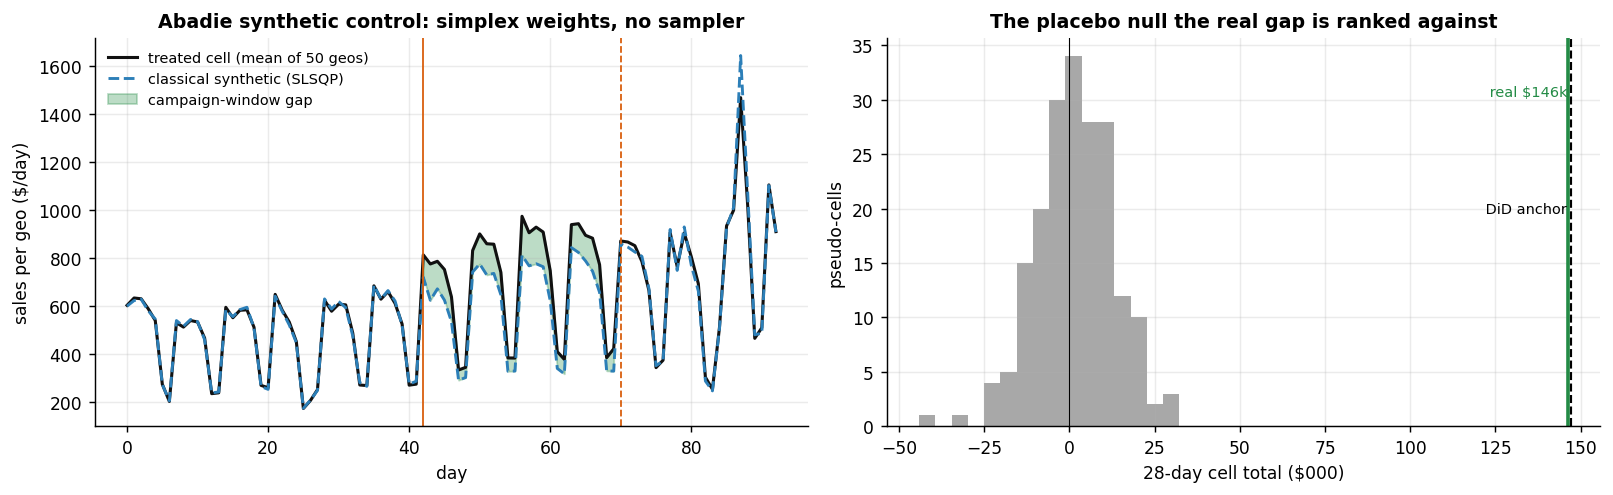

In [3]:
from cmp import classical as cl

# ---- 1 · THE REFEREE: matched-pairs DiD. Randomization licenses it; it fits no model at all. ----
pairs = [(a, a + 1) for a in range(1, 100, 2)]        # consecutive size-ranked geos...
assert all({int(group[a]), int(group[b])} == {1, 2} for a, b in pairs), "not a matched-pairs design"
assert panel.iloc[pre].mean().idxmax() == 1, "data card: geo 1 (numbered by size) should be the largest pre-launch"
pair_diffs = np.array([                                # ...verified 1 treated + 1 control in each
    (panel[tr].values[post].mean() - panel[tr].values[pre].mean())
    - (panel[ctl].values[post].mean() - panel[ctl].values[pre].mean())
    for a, b in pairs for tr, ctl in [((a, b) if group[a] == 2 else (b, a))]])
did_total = float(pair_diffs.mean() * n_treat * n_days)                       # $000s, cell total
did_se = float(pair_diffs.std(ddof=1) / np.sqrt(len(pairs)) * n_treat * n_days)
did_cl = cl.Classical("Total incremental sales (matched-pairs DiD)", did_total, did_se,
                      (did_total - 1.645 * did_se, did_total + 1.645 * did_se), 0.10,
                      f"matched-pairs randomization; SE from the {len(pairs)} pair differences",
                      n=len(panel.columns), extra={"iroas": did_total / SPEND})

# What the PAIRING bought: the identical contrast, computed while ignoring the pairs (Welch SE on the
# 100 geo-level changes). Same estimand, same randomization, a strictly worse use of the design.
chg = {g: panel[g].values[post].mean() - panel[g].values[pre].mean() for g in panel.columns}
unpaired = cl.diff_in_means(np.array([chg[g] for g in treated_geos + control_geos]),
                            np.r_[np.ones(n_treat, bool), np.zeros(len(control_geos), bool)])
unp_se = unpaired.se * n_treat * n_days

# ---- 2 · THE CONTESTANT: classical synthetic control, SLSQP simplex weights, PRE-period only ----
slsqp_gap, w_cl = est.sc_effect_slsqp(y_tr, donors, pre, post)     # gap = treated cell - synthetic
slsqp_total = float(slsqp_gap[post].sum() * n_treat)               # $000s of incremental sales
pre_rmse_cl = float(np.sqrt(np.mean(slsqp_gap[pre] ** 2)))
eff_n_cl = 1.0 / np.sum(w_cl ** 2)                                 # effective donors (inverse Herfindahl)

# ---- 3 · INFERENCE for the SC arm, with no likelihood: pseudo-cell permutation (Abadie) ----
def rmse_ratio(gap):                                    # scale-free statistic: post RMSE / pre RMSE
    return float(np.sqrt(np.mean(gap[post] ** 2)) / max(np.sqrt(np.mean(gap[pre] ** 2)), 1e-9))

real_ratio, real_gap_mean = rmse_ratio(slsqp_gap), float(slsqp_gap[post].mean())
rng = np.random.default_rng(7)
paths, ratios_p, gaps_p, prermse_p = [], [], [], []
for b in range(N_PSEUDO):                               # Depth B reuses every one of these arrays
    half = rng.choice(len(control_geos), 25, replace=False)        # a 25-geo pseudo-cell...
    rest = np.setdiff1d(np.arange(len(control_geos)), half)        # ...fitted from the other 25
    y_p = panel[[control_geos[i] for i in half]].mean(axis=1).values
    gp, _ = est.sc_effect_slsqp(y_p, donors[rest], pre, post)
    paths.append(gp); ratios_p.append(rmse_ratio(gp)); gaps_p.append(gp[post].mean())
    prermse_p.append(float(np.sqrt(np.mean(gp[pre] ** 2))))
ratios_p, gaps_p, prermse_p = np.array(ratios_p), np.array(gaps_p), np.array(prermse_p)
p_gap = (np.sum(np.abs(gaps_p) >= abs(real_gap_mean)) + 1) / (N_PSEUDO + 1)
p_ratio = (np.sum(ratios_p >= real_ratio) + 1) / (N_PSEUDO + 1)

# An interval WITHOUT a likelihood: Abadie's pre-fit filter, then invert the placebo null of the total.
placebo_tot = gaps_p * n_days * n_treat                 # cell totals ($000s) under "no campaign"
keep_pl = prermse_p <= 5 * pre_rmse_cl                  # discard pseudo-cells the synthetic can't track
pl_kept = placebo_tot[keep_pl]
ri_lo = float(slsqp_total - np.quantile(pl_kept, 0.95)) # inversion: estimate - the null's tails
ri_hi = float(slsqp_total - np.quantile(pl_kept, 0.05))
sc_cl = cl.Classical("Total incremental sales (classical SC)", slsqp_total,
                     float(pl_kept.std(ddof=1)), (ri_lo, ri_hi), 0.10,
                     f"placebo randomization ({int(keep_pl.sum())} pseudo-cells, Abadie 5x pre-fit filter)",
                     n=len(control_geos), extra={"p_rmse_ratio": p_ratio})

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax[0].plot(t, y_tr * 1000, color="#111", lw=1.7, label="treated cell (mean of 50 geos)")
ax[0].plot(t, (y_tr - slsqp_gap) * 1000, color=plots.BLUE, ls="--", lw=1.6, label="classical synthetic (SLSQP)")
ax[0].fill_between(t[post], (y_tr - slsqp_gap)[post] * 1000, y_tr[post] * 1000,
                   color=plots.GREEN, alpha=0.3, label="campaign-window gap")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax[0].set_xlabel("day"); ax[0].set_ylabel("sales per geo ($/day)")
ax[0].set_title("Abadie synthetic control: simplex weights, no sampler")
ax[0].legend(frameon=False, fontsize=8)
ax[1].hist(pl_kept, bins=16, color=plots.GREY, alpha=0.85)
ax[1].axvline(slsqp_total, color=plots.GREEN, lw=2)
ax[1].text(slsqp_total, ax[1].get_ylim()[1] * 0.85, f" real ${slsqp_total:.0f}k", fontsize=8,
           color=plots.GREEN, ha="right")
ax[1].axvline(did_total, color="k", ls="--", lw=1.2)
ax[1].text(did_total, ax[1].get_ylim()[1] * 0.55, " DiD anchor ", fontsize=8, ha="right")
ax[1].axvline(0, color="k", lw=0.6)
ax[1].set_xlabel(f"{n_days}-day cell total ($000)"); ax[1].set_ylabel("pseudo-cells")
ax[1].set_title("The placebo null the real gap is ranked against")
fig.tight_layout()

print(f"THE REFEREE, matched-pairs DiD over {len(pairs)} randomized pairs.")
print( "  No model, no donor weights, no counterfactual: only the coin flip.")
print(f"  total incremental sales ${did_total:.0f}k   90% CI "
      f"[${did_cl.ci[0]:.0f}k, ${did_cl.ci[1]:.0f}k]   (SE ${did_se:.0f}k)")
print(f"  covariance: {did_cl.cov}")
print(f"  iROAS {did_total / SPEND:.2f}  [{did_cl.ci[0] / SPEND:.2f}, "
      f"{did_cl.ci[1] / SPEND:.2f}]  on ${SPEND:.0f}k of spend")
print(f"  what PAIRING bought: ignore the pairs and the same contrast gives the")
print(f"      same point (${unpaired.estimate * n_treat * n_days:.0f}k) with SE "
      f"${unp_se:.0f}k -> pairing cuts the SE {unp_se / did_se:.1f}x, by design")
print(f"  UNBIASED by construction, and still ±${1.645 * did_se:.0f}k wide.")
print( "  Unbiasedness is NOT precision: that width is the variance the model cuts.")

print(f"\nTHE CONTESTANT, classical SC (SLSQP), fit on days 0-{launch - 1} only")
print(f"  {len(control_geos)} donors: {(w_cl > 0.01).sum()} carry >1% of the weight; "
      f"{eff_n_cl:.0f} effective donors (1/sum w^2)")
print(f"  pre-fit RMSE ${pre_rmse_cl * 1000:.0f}/geo/day on a ~${y_tr[pre].mean() * 1000:.0f} "
      f"level ({pre_rmse_cl / y_tr[pre].mean():.1%}), the gate the gap rests on")
print(f"  total incremental sales ${slsqp_total:.0f}k  ·  iROAS {slsqp_total / SPEND:.2f}"
      f"  ·  ${slsqp_gap[post].mean() * 1000:+.0f}/geo/day")
print(f"  GRADE vs the randomized referee: off by ${slsqp_total - did_total:+.0f}k "
      f"({abs(slsqp_total - did_total) / did_se:.2f} anchor SEs)")
print(f"      -> {'INSIDE' if did_cl.ci[0] <= slsqp_total <= did_cl.ci[1] else 'OUTSIDE'}"
      f" the anchor's 90% CI")

_bad = np.where(~keep_pl)[0]
_p_filt = (np.sum(np.abs(pl_kept) >= abs(slsqp_total)) + 1) / (int(keep_pl.sum()) + 1)
print("\nINFERENCE, no likelihood, so no standard error. Rank the real cell")
print("            against pseudo-cells that never saw an ad dollar, then")
print("            invert that null into an interval:")
print(f"  Abadie RMSE-ratio p = {p_ratio:.3f}  (real cell {real_ratio:.1f} vs a placebo "
      f"median of {np.median(ratios_p):.1f})")
print(f"  raw-gap permutation p = {p_gap:.3f}  "
      f"({int((np.abs(gaps_p) >= abs(real_gap_mean)).sum())} of {N_PSEUDO} pseudo-cells beat it)")
# The filter may legitimately discard NOTHING, and on this data it does: the treated cell averages
# 50 geos while a pseudo-cell averages 25, so the treated cell's synthetic fits far better than any
# pseudo-cell's can, and Abadie's 5x bar sits above the whole null. Narrating "the worst discarded
# cell" unconditionally used to crash here (max of an empty array), report what happened instead.
if _bad.size:
    print(f"  the pre-fit filter discards {_bad.size} of {N_PSEUDO} pseudo-cells "
          f"(pre-RMSE up to {prermse_p.max() / pre_rmse_cl:.0f}x")
    print(f"      the real cell's). The worst carries a |total| of "
          f"${np.abs(placebo_tot[_bad]).max():.0f}k, a bundle whose")
    print(f"      own synthetic cannot reach it: Depth A's convex-hull failure,")
    print(f"      arriving uninvited. Filtered, the raw-gap p becomes {_p_filt:.3f}.")
else:
    print(f"  the pre-fit filter discards NONE of the {N_PSEUDO} pseudo-cells: the worst-fitting one")
    print(f"      sits at {prermse_p.max() / pre_rmse_cl:.1f}x the real cell's pre-RMSE, inside Abadie's 5x bar.")
    print(f"      Note WHY the bar is generous here: the treated cell averages {n_treat} geos and a")
    print(f"      pseudo-cell only 25, so the real cell's synthetic tracks better than any placebo's")
    print(f"      can, the filter is comparing unlike with unlike, and it flatters the treated fit.")
    print(f"      Nothing is filtered, so the raw-gap p is unchanged at {_p_filt:.3f}.")
print(f"  90% randomization interval on the total (placebo null, inverted):")
print(f"      [${ri_lo:.0f}k, ${ri_hi:.0f}k], width ${ri_hi - ri_lo:.0f}k, vs the DiD "
      f"referee's ${did_cl.ci[1] - did_cl.ci[0]:.0f}k")
print()
print(did_cl.cannot_say())


**Read-out, no priors, no sampler, and the question is already answered.** Read the three blocks above in
order. The **referee** says the campaign generated the total printed on the first line, an iROAS near 3, and
it says so with no model at all, only the coin flip. Note the two honest details the print-out volunteers:
pairing cuts the standard error by the factor shown (a *design* choice worth more than any estimator choice),
and the anchor is nonetheless **wide**, its 90% interval reaches nearly half the effect's size in each
direction. Unbiasedness is not precision. That width is the entire commercial reason to fit a model on top of
a perfectly good experiment.

The **contestant**, classical synthetic control, the estimator we will still own when nobody randomizes
anything, tracks the treated cell before launch to within the printed pre-fit RMSE (~1.5% of the level), and
then lands within a fraction of one anchor SE of the referee's point, **inside** its 90% interval. That is the
exam, and it is the only exam real data can set: 07 could grade against a planted truth, and here the
randomization *is* the truth we grade against. The method passes it.

The **inference** block is where the classical arm shows its real character. The permutation p-value is a
**randomization-inference** statement: *if the campaign had done nothing, a post-window jump this extreme, 
relative to its own pre-fit, would have turned up in about this fraction of untreated bundles.* Watch what
the pre-fit filter did, the code handles both outcomes, and the printed read-out adjudicates. In *this*
run it discarded a handful of bundles whose own synthetics cannot track them before launch (pre-RMSE many
times the real cell's, the worst of them carrying the largest raw |total| in the null): not evidence of a
rival effect but a **broken fit**, the same convex-hull failure Depth A stages deliberately with geo 1, 
and Abadie's filter, plus the scale-free RMSE ratio, is precisely the machinery that refuses to be fooled
by it; the filtered raw-gap p is printed above. (The filter can equally well discard *nothing*, the
print-out explains why the 5× bar is generous for a 50-geo cell judged against 25-geo placebos, so read
the cell's own verdict, not this paragraph, for which branch this execution took.)

**And now the boundary, the same one this cookbook states in every notebook.** Both classical intervals above
are *confidence* intervals, and the guardrail printed at the end of the cell applies to each of them: 90% of
intervals built that way cover the truth **across repeated randomizations**; *this* one either covers it or it
does not. The permutation p is stricter still, it ranks the observed data against a null and attaches **no
probability to any hypothesis about the effect**. So neither object can be read as "there is a 90% chance the
lift is between these numbers," and, the part that actually bites, **neither can answer the question §6 has to
sign off on**: *what is the probability this campaign was profitable at a 35% gross margin?* That is a
probability **about the effect**, weighed against a cost the p-value has never met. It exists only in a
posterior. §4 builds one; §5x then asks, with the design-based scale we just constructed, whether it is a
*trustworthy* one.

## 4 · Estimate, Bayesian synthetic control on the test cell

Same model as 07, and the same objective Step 0 just solved with SLSQP, now re-housed in a prior rather
than an optimizer: **Dirichlet-simplex weights** over the 50 control geos, fit to the 42 pre-launch
days, returning a posterior over the counterfactual path, and therefore over total lift and iROAS.
Read three things off the fit, exactly as in 07: **which donors** carry weight (the Dirichlet
spreads it, expect a high "effective number of donors" on a mean-of-50 target), the **pre-fit
RMSE** (Step 5 turns it into a PASS/FAIL gate), and the **counterfactual band** (a posterior
predictive, carrying the cell's own daily noise, not just weight uncertainty).

**And read the convergence line, including the divergences.** The sampler already runs at
`target_accept = 0.99`, yet NUTS still reports some divergent transitions (the exact count, r-hat,
and ESS are printed below). The geometry is the suspect: 50 simplex weights pressed against a noise
scale of ~2% of the level create funnel-like corners the integrator occasionally overshoots. We do
*not* wave this away, divergences are the one warning that can invalidate a fit even when r-hat
looks perfect. Two checks argue these are benign: the r-hat/ESS readout below says the chains agree on the
same posterior (**r-hat** near 1.0 means the independent chains landed on the same distribution; **ESS**, effective sample size, is the number of *effectively independent* draws behind each estimate, and the several thousand printed below is healthy), and, decisive, Step 0 already solved the *same* objective with a divergence-free optimizer (SLSQP samples nothing, so it cannot diverge), and Step 5 prints how far the two totals sit apart (a small fraction of the posterior's own 90%
width). If that cross-check disagreed, the right move would be reparameterization, not narration.

[cache] loaded '07b_sc_bayes' (53s fit, cached 95.5h ago) — nothing re-sampled.
SC sampling convergence: max r-hat 1.000 - min ESS 2335 - divergences 1


pre-fit RMSE $10/geo/day on a ~$472 level (~2%)
total incremental sales $149k  90% CI [$141k, $158k]  on $50k of spend
revenue iROAS 2.98  90% CI [2.81, 3.15]


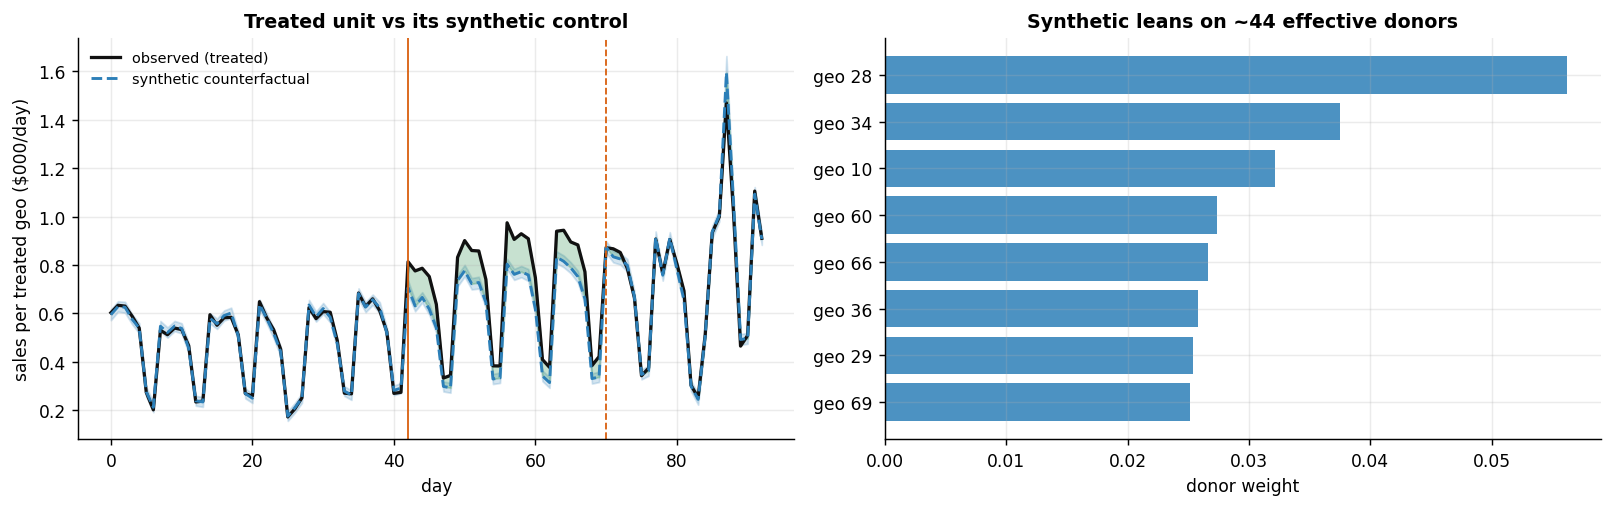

In [4]:
sc = load_or_run("07b_sc_bayes",
                 lambda: est.synthetic_control(y_tr, donors, pre, post, seed=SEED,
                                               target_accept=0.99, **SC),
                 inputs=dict(seed=SEED, fast=FAST, model="iid", target_accept=0.99, **SC))
print(f"SC sampling convergence: {sc['convergence']['summary']}")
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1) * n_treat          # $000s of incremental sales, cell total
iroas = total_post / SPEND
w_mean = sc["weight_samples"].mean(0)
eff_n = 1.0 / np.sum(w_mean ** 2)
topw = np.argsort(-w_mean)[:8]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch, xlabel="day",
                             ylabel="sales per treated geo ($000/day)")
ax[0].axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax[1].barh([f"geo {control_geos[i]}" for i in topw][::-1], w_mean[topw][::-1],
           color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on ~{eff_n:.0f} effective donors")
fig.tight_layout()

lo, hi = np.quantile(total_post, [0.05, 0.95]); lo_r, hi_r = np.quantile(iroas, [0.05, 0.95])
print(f"pre-fit RMSE ${sc['pre_rmse'] * 1000:.0f}/geo/day on a ~${y_tr[pre].mean() * 1000:.0f} level (~2%)")
print(f"total incremental sales ${total_post.mean():.0f}k  90% CI [${lo:.0f}k, ${hi:.0f}k]  on ${SPEND:.0f}k of spend")
print(f"revenue iROAS {iroas.mean():.2f}  90% CI [{lo_r:.2f}, {hi_r:.2f}]")

## 5 · Validate, against the randomized experiment

Four checks. The first is the one no simulator can fake, and Step 0 has already built it: an *unbiased,
design-based* estimate of the same estimand, from the experiment's own randomization.

1. **The matched-pairs DiD anchor** (Step 0). It is our stand-in for 07's planted truth: **the synthetic
   control point must land inside its interval**, and the chart below draws the anchor straight across the
   gap path so you can see the daily lift agree with it. Note again how *wide* that interval is:
   unbiasedness isn't precision, and cutting exactly that variance is what the model is here to do. (§5x
   then turns the comparison around and asks whether the model's *narrowness* is honest.)
2. **Pre-fit gate**, same concrete rule as 07: pre-RMSE below a third of the daily lift the design must
   detect, printed PASS/FAIL.
3. **The off-switch falsification.** The spend stops on day 70; a real advertising effect should collapse
   toward zero in the 23-day cooldown (up to carryover). A gap that *persists* after the money stops would
   smell of a confound rather than a campaign. This replaces the simulator's "we know the truth after week
   40" with a physical prediction the data can refute.
4. **Leave-one-out donors**, drop each top-weighted donor, refit (fast SLSQP), watch stability.

**What we cannot do on real data**, and say so plainly, as 07's multi-seed check taught us: we cannot refit
on fresh copies of the world, so we cannot *measure* interval calibration here. But we are not reduced to
quoting 07's warning either: Step 0's placebo distribution is the same estimator run under a known null, and
**§5x prices the posterior's band against it**, the closest thing to a calibration check that one real
dataset permits. Trust the placebo permutation (Depth B) for significance, not the band width alone.


anchor (Step 0): matched-pairs DiD total $147k ± 42 (90% CI [78, 216]k; iROAS 2.94 [1.56, 4.32])
        SC total $149k (iROAS 2.98), lands on the anchor's point with a ~8x tighter band, the variance reduction SC exists for. Is that narrowness honest? 5x prices it.
pre-fit gate: pre-RMSE $10 vs |daily lift|/3 = $36  ->  PASS
off-switch: campaign-window gap $+107/geo/day  ->  cooldown $-3/geo/day (collapses when the spend stops, and no long carryover to book as extra value)
leave-one-out: total ranges $145–151k vs SLSQP baseline $146k, no single donor drives it
divergence cross-check: 1 divergent transition, but the divergence-free SLSQP refit of the same objective lands $2.9k from the Bayesian total (17% of the 90%-CI width) -> benign (simplex funnel corners, not bias)
interpolation check (a): dropping the 10 gappy donors (near-uniform Dirichlet weight 19%) moves the daily lift $+104 -> $+104/geo/day (0.3% shift) -> interpolation is immaterial
interpolation check (b): dropping all 17 g

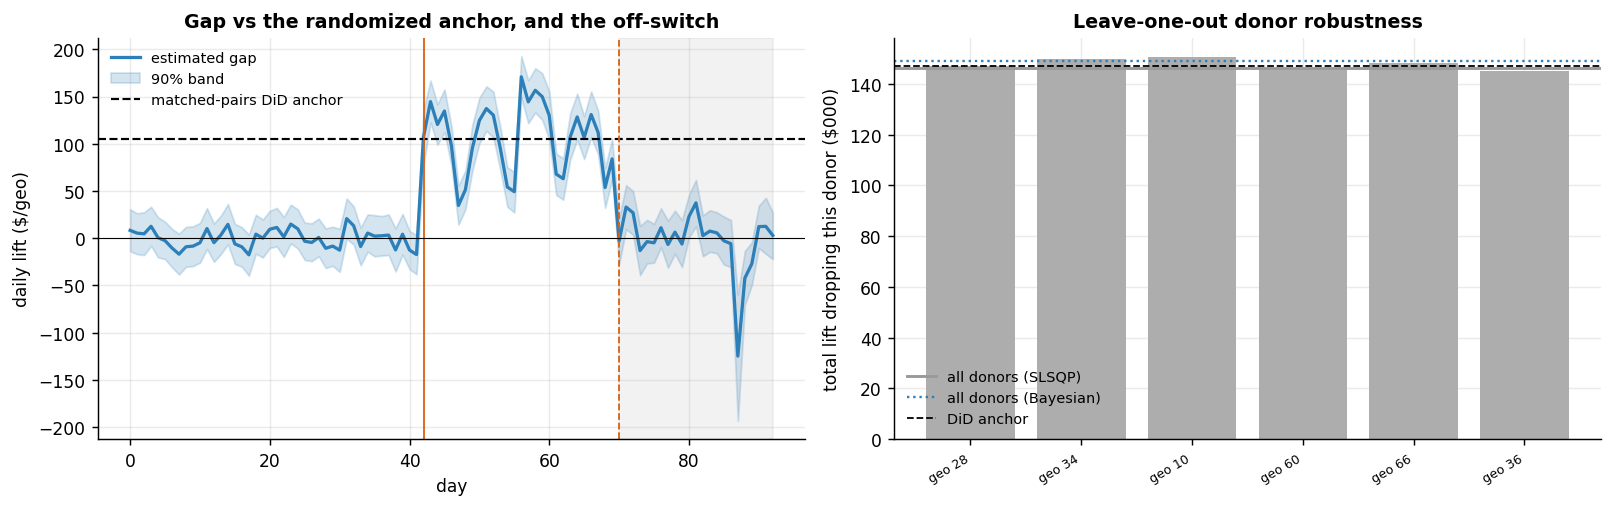

In [5]:
# 1) the anchor, the classical SC and their weights all come from Step 0, reused, not refitted:
#    pair_diffs / did_total / did_se (the randomized referee) and slsqp_gap / slsqp_total (the SC point).

# 2) pre-fit gate (non-oracle: uses the estimated daily lift)
daily_lift = total_post.mean() / n_treat / n_days
gate_ref = abs(daily_lift) / 3
gate = "PASS" if sc["pre_rmse"] < gate_ref else "FAIL"

# 3) off-switch: mean gap in the cooldown vs in the campaign window
eff_mean = effect.mean(0); eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
cool_gap, post_gap = eff_mean[cool].mean(), eff_mean[post].mean()

# 4) leave-one-out (fast SLSQP, same-fitter baseline as 07, Step 0's fit is the all-donor baseline)
loo = []
for i in topw[:6]:
    keep = [k for k in range(len(control_geos)) if k != i]
    gp, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gp[post].sum() * n_treat)

# 5) interpolation robustness (supports the §7 caveat), two reruns (cheap SLSQP):
#    (a) drop the gappy DONORS only, same estimand, tests whether interpolated donor
#        values feed the counterfactual;
#    (b) drop gappy geos on BOTH sides, the cell becomes a mean of the surviving
#        (larger) geos, so its per-geo lift must be graded against the matched-pairs
#        anchor restricted to the same pairs, not against the full cell.
gappy = set(raw_panel.columns[raw_panel.isna().any()])
gappy_w = float(w_mean[[i for i, g in enumerate(control_geos) if g in gappy]].sum())
keep_ng = [i for i, g in enumerate(control_geos) if g not in gappy]
gap_dnr, _ = est.sc_effect_slsqp(y_tr, donors[keep_ng], pre, post)
tr_ng = [g for g in treated_geos if g not in gappy]
y_ng = panel[tr_ng].mean(axis=1).values
gap_ng, _ = est.sc_effect_slsqp(y_ng, donors[keep_ng], pre, post)
anchor_ng = pair_diffs[[i for i, (a, b) in enumerate(pairs)
                        if (a if group[a] == 2 else b) in tr_ng]].mean()

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean * 1000, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo * 1000, eff_hi * 1000, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].axhline(pair_diffs.mean() * 1000, color="k", ls="--", lw=1.2, label="matched-pairs DiD anchor")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax[0].axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("day"); ax[0].set_ylabel("daily lift ($/geo)")
ax[0].set_title("Gap vs the randomized anchor, and the off-switch")
ax[0].legend(frameon=False, fontsize=8)
ax[1].axhline(slsqp_total, color=plots.GREY, lw=1.6, label="all donors (SLSQP)")
ax[1].axhline(total_post.mean(), color=plots.BLUE, ls=":", lw=1.3, label="all donors (Bayesian)")
ax[1].axhline(did_total, color="k", ls="--", lw=1, label="DiD anchor")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo)))
ax[1].set_xticklabels([f"geo {control_geos[i]}" for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor ($000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()

print(f"anchor (Step 0): matched-pairs DiD total ${did_total:.0f}k ± {did_se:.0f} "
      f"(90% CI [{did_total - 1.645 * did_se:.0f}, {did_total + 1.645 * did_se:.0f}]k; iROAS "
      f"{did_total / SPEND:.2f} [{(did_total - 1.645 * did_se) / SPEND:.2f}, {(did_total + 1.645 * did_se) / SPEND:.2f}])")
print(f"        SC total ${total_post.mean():.0f}k (iROAS {iroas.mean():.2f}), lands on the anchor's point "
      f"with a ~{(1.645 * did_se) / ((hi - lo) / 2):.0f}x tighter band, the variance reduction SC exists for. Is that narrowness honest? 5x prices it.")
print(f"pre-fit gate: pre-RMSE ${sc['pre_rmse'] * 1000:.0f} vs |daily lift|/3 = ${gate_ref * 1000:.0f}  ->  {gate}")
print(f"off-switch: campaign-window gap ${post_gap * 1000:+.0f}/geo/day  ->  cooldown ${cool_gap * 1000:+.0f}/geo/day "
      f"(collapses when the spend stops, and no long carryover to book as extra value)")
print(f"leave-one-out: total ranges ${min(loo):.0f}–{max(loo):.0f}k vs SLSQP baseline ${slsqp_total:.0f}k, "
      f"no single donor drives it")
print(f"divergence cross-check: {sc['convergence']['n_divergences']} divergent transition{'s' if sc['convergence']['n_divergences'] != 1 else ''}, but the "
      f"divergence-free SLSQP refit of the same objective lands ${abs(total_post.mean() - slsqp_total):.1f}k "
      f"from the Bayesian total ({abs(total_post.mean() - slsqp_total) / (hi - lo):.0%} of the 90%-CI width) "
      f"-> benign (simplex funnel corners, not bias)")
print(f"interpolation check (a): dropping the {len(control_geos) - len(keep_ng)} gappy donors "
      f"(near-uniform Dirichlet weight {gappy_w:.0%}) moves the daily lift "
      f"${slsqp_gap[post].mean() * 1000:+.0f} -> ${gap_dnr[post].mean() * 1000:+.0f}/geo/day "
      f"({abs(gap_dnr[post].mean() / slsqp_gap[post].mean() - 1):.1%} shift) -> interpolation is immaterial")
print(f"interpolation check (b): dropping all {len(gappy)} gappy geos on both sides gives "
      f"${gap_ng[post].mean() * 1000:+.0f}/geo/day for the surviving {len(tr_ng)}-geo cell, pure composition "
      f"(bigger geos, bigger per-geo lift), matched by the anchor on the same pairs "
      f"(${anchor_ng * 1000:+.0f}); relative lift {slsqp_gap[post].mean() / y_tr[pre].mean():.1%} vs "
      f"{gap_ng[post].mean() / y_ng[pre].mean():.1%}, unchanged")

**Read-out.** The synthetic control lands almost exactly on the randomized answer, 
**$149k vs the anchor's $147k** (iROAS 2.98 vs 2.94), passing the only exam real data can set. And
the comparison teaches why the model exists at all: the *unbiased* anchor carries a wide 90% interval
(heavy-tailed geo sizes make even 50 randomized pairs noisy), while SC's band is several times tighter
around the same point, a narrowness §5x will hold up against the design's own scale before we spend it. The gap path shows a clean rectangle: nothing before day 42, a
sustained ~$105/geo/day lift during the four paid weeks, and a collapse to ≈ −$3/geo/day within the
cooldown, the effect **switches off when the money does**, which simultaneously validates the
attribution and tells the media planner there is no adstock annuity to book. Leave-one-out totals
move by ~$3k on a $147k estimate: no single market carries the result.

One more benchmark, this time from the published record. This is the worked-example dataset released
with Google's geo-experiment methodology, and the time-based-regression (TBR) analysis published
alongside it, Kerman, Wang & Vaver (2017), [*Estimating Ad Effectiveness using Geo Experiments in a
Time-Based Regression Framework*](https://research.google/pubs/estimating-ad-effectiveness-using-geo-experiments-in-a-time-based-regression-framework/),
run on this same sales-and-cost panel by the `GeoexperimentsResearch` vignette, reads out an iROAS of
the same sign and order as the 2.94–2.98 the two arms above agree on. We cite that readout rather than
retype it (the paper's own numerical example is a different, anonymized experiment, so no exact figure
for this panel appears in the paper itself), but it is a third, independent estimator family landing on
the same answer.

### 5x · Point estimate vs posterior, what the Bayesian layer actually bought

Step 0 produced two model-free numbers and an interval with no likelihood, prior or sampler; §4 produced a
posterior. All three target the **same estimand**, total incremental sales over the 28-day window, so lay
them side by side on it. Then do the thing this notebook can do and 07 could only simulate: hold the
posterior's interval up against a **design-based** scale for the very same quantity. We cannot resample the
world here (no fresh panels, no planted truth), so we cannot *measure* coverage, but we do not have to guess
either. The randomized anchor hands us an analytic SE, and the pseudo-cell placebos of Step 0 hand us the
distribution *the same SC estimator* produces from noise alone. Those are the referees for **width**, exactly
as the anchor is the referee for **location**. Nothing below is asserted; all of it is computed.

In [6]:
# --- 5x · Classical vs posterior, on the SAME estimand: total incremental sales ---
# Location, width, and the decision, each measured against something outside the model.
from scipy.stats import norm
from cmp import report

post_lo, post_hi = np.quantile(total_post, [0.05, 0.95])
rows5x = [("matched-pairs DiD · THE REFEREE (design)", did_total, did_cl.ci[0], did_cl.ci[1]),
          ("classical SC (SLSQP) · placebo CI", slsqp_total, ri_lo, ri_hi),
          ("Bayesian SC (Dirichlet) · posterior", float(total_post.mean()),
           float(post_lo), float(post_hi))]
print(f"SAME estimand, total incremental sales over the {n_days} campaign days.")
print(f"No planted truth exists: the randomized DiD is the benchmark the two")
print(f"model-based rows must match.\n")
print(f"{'':<40}{'est':>6}{'iROAS':>7}{'5%':>6}{'95%':>6}{'width':>7}")
for lab, e, lo_, hi_ in rows5x:
    print(f"{lab:<40}{e:>6.0f}{e / SPEND:>7.2f}{lo_:>6.0f}{hi_:>6.0f}{hi_ - lo_:>7.0f}")

print(f"\nLOCATION, they agree, and that agreement is the notebook's exam. Both")
print(f"  model-based estimates sit INSIDE the referee's 90% CI: classical SC "
      f"{abs(slsqp_total - did_total) / did_se:.2f}")
print(f"  anchor SEs from its point, the posterior mean "
      f"{abs(total_post.mean() - did_total) / did_se:.2f}.")
print(f"  The Bayesian layer moved the point estimate by "
      f"${abs(total_post.mean() - slsqp_total):.1f}k "
      f"({abs(total_post.mean() - slsqp_total) / slsqp_total:.1%})")
print(f", it did not buy a better one.")

# WIDTH. Three rival scales for the sd of the same total. The posterior's is the only one
# that comes from a likelihood; the other two come from the design.
sd_post = float(total_post.std())
sd_pl = float(pl_kept.std(ddof=1))     # the SAME SC estimator, refit on untreated pseudo-cells
sd_pl_adj = sd_pl / np.sqrt(2)         # deflated: a 25-geo pseudo-cell carries ~2x the real
                                       # cell's idiosyncratic variance -> the conservative floor
print(f"\nWIDTH, they do not. Three rival scales for the sd of that same total:")
print(f"  posterior sd (iid likelihood, one dataset)   ${sd_post:>5.1f}k")
print(f"  placebo sd, the SAME estimator, no ads      ${sd_pl:>5.1f}k  "
      f"({sd_pl / sd_post:.1f}x)")
print(f"    deflated for the 25-vs-50-geo mismatch     ${sd_pl_adj:>5.1f}k  "
      f"({sd_pl_adj / sd_post:.1f}x)  <- fair floor")
print(f"  DiD anchor's SE (a DIFFERENT estimator)      ${did_se:>5.1f}k  "
      f"({did_se / sd_post:.1f}x)")
print(f"  -> the posterior underprices the SC estimator's OWN sampling noise by")
print(f"     ~{sd_pl_adj / sd_post:.1f}-{sd_pl / sd_post:.1f}x. The anchor's "
      f"{did_se / sd_post:.0f}x is NOT that verdict: an unweighted DiD is a")
print(f"     genuinely noisier estimator, and cutting its variance is what SC is FOR.")
print(f"     The fair referee re-runs OUR estimator under a known null, the placebos.")
# Cross-notebook citation, READ not retyped: 07 measures how far its iid posterior
# under-prices its referee's sd and emits the factor as nb07.underprice. peek() returns
# the live value, or None if 07's shard has not been (re)built yet, hedge, never crash.
factor = report.peek("nb07.underprice")
if factor is not None:
    print(f"     notebook 07, where fresh worlds were free, MEASURED this same failure: the iid")
    print(f"     posterior under-priced the referee sd by ~{factor:.1f}x, and the 90% band built")
else:
    print(f"     notebook 07, where fresh worlds were free, MEASURED this same failure: the iid")
    print(f"     posterior under-priced the referee sd by roughly a factor of two, and the 90% band built")
print(f"     from it covered the planted total only about half the time, not 90%. Same direction,")
print(f"     same cause: an iid likelihood on a gap whose errors are persistent -> the variance")
print(f"     of a SUM is underpriced.")

# THE DECISION, the one object the classical arm cannot produce, and what the honest
# scale does to it.
p_go_post = float(policy.go_no_go(total_post * MARGIN, SPEND)["P_value_gt_cost"])
print(f"\nP(profitable at a {MARGIN:.0%} margin), the number §6 signs off on:")
print(f"  classical (a CI or a p-value)               not defined")
for sd_, lab in [(sd_post, "Bayesian posterior (§4)"),
                 (sd_pl_adj, "re-priced at the placebo floor"),
                 (sd_pl, "re-priced at the raw placebo sd"),
                 (did_se, "re-priced at the anchor's SE")]:
    d_ = policy.go_no_go(norm.rvs(loc=total_post.mean(), scale=sd_, size=80_000,
                                  random_state=7) * MARGIN, SPEND)
    print(f"  {lab:<42}{d_['P_value_gt_cost']:>5.2f}  -> {d_['decision']}")
print(f"  ('not defined' is no dodge: a p-value ranks data against a null; it")
print(f"   attaches no probability to a hypothesis about the effect, and it has")
print(f"   never met the ${SPEND:.0f}k of spend or the {MARGIN:.0%} margin.)")
print(f"  -> same centre, honest scale: P(profitable) falls from {p_go_post:.2f}. The CALL")
print(f"     survives (the 0.90 bar is not crossed either way), but the confidence")
print(f"     attached to it was borrowed, not earned.")

SAME estimand, total incremental sales over the 28 campaign days.
No planted truth exists: the randomized DiD is the benchmark the two
model-based rows must match.

                                           est  iROAS    5%   95%  width
matched-pairs DiD · THE REFEREE (design)   147   2.94    78   216    138
classical SC (SLSQP) · placebo CI          146   2.93   127   164     37
Bayesian SC (Dirichlet) · posterior        149   2.98   141   158     17

LOCATION, they agree, and that agreement is the notebook's exam. Both
  model-based estimates sit INSIDE the referee's 90% CI: classical SC 0.02
  anchor SEs from its point, the posterior mean 0.05.
  The Bayesian layer moved the point estimate by $2.9k (2.0%)
, it did not buy a better one.

WIDTH, they do not. Three rival scales for the sd of that same total:
  posterior sd (iid likelihood, one dataset)   $  5.1k
  placebo sd, the SAME estimator, no ads      $ 11.6k  (2.3x)
    deflated for the 25-vs-50-geo mismatch     $  8.2k  (1.6x)

**1 · On the number itself, all three agree, and the model is not the hero.** The randomized anchor, the
classical SLSQP fit and the Bayesian posterior mean land on top of each other (printed above: the two
model-based estimates sit a small fraction of one anchor SE from the referee, well inside its interval). Say
this plainly, because it is the whole point of running a companion notebook on real data: **the Bayesian layer
did not buy a better point estimate.** It could not have. The causal work was done by the *design*, a coin
flip across 50 matched pairs, and, for the SC arm, by §3's identification and the simplex. Both estimators
share that work; the sampler adds none of it. What the SC arm *does* buy over the anchor is **precision**: the
same answer with a far narrower interval, which is exactly why we bother fitting a model on top of a perfectly
good experiment, and exactly why we must now ask whether that narrowness is real.

**2 · On the uncertainty, they disagree, and the posterior is the optimistic one.** This is the uncomfortable
finding, and it is measured, not imported. Three numbers price the same object. The posterior's sd comes from a
likelihood that treats the daily gaps as **iid**. The placebo sd comes from re-running *our own estimator* on
25-geo bundles that saw no advertising, the design's own answer to "how much does this estimator wander when
the true effect is zero?", and even after deflating it for the fact that a 25-geo bundle is noisier than the
real 50-geo cell (the conservative floor printed above), it is **~1.6–2.2× wider than the posterior believes.**
That is the same failure 07 diagnosed and *quantified* on simulated worlds, where fresh panels were free: there,
the posterior **under-priced its own sd by the factor the companion measured, printed above, read live
from 07's own export rather than retyped here**, and the 90% band it built from that sd went on to cover the
planted total only about half the time, not 90% (a width error and the coverage shortfall it causes: two statements,
not one), because the synthetic's error is not fresh noise each day but a
**persistent offset**, the unmatched share of the shared factors, so the variance of a *sum* over the window
picks up covariance terms the iid likelihood sets to zero. We cannot re-run the world here to measure coverage.
We did not need to: the design handed us a scale, and it says the band is too tight. The notebook's §7 caveat
about "interval optimism" was, until this section, an *imported* claim from 07; it is now a **measured** one on
this dataset.

One thing this does *not* say, and the print-out is careful about it: the anchor's SE is ~8× the posterior's,
and that ratio is **not** the indictment. An unweighted matched-pairs DiD is a genuinely noisier estimator than
a donor-matched synthetic control, cutting that variance is the entire job of the model, and it really does cut
it. The fair referee for the posterior's *width* is the placebo distribution of the **same** estimator, and that
referee returns a verdict of roughly two, not eight. Both statements are true at once: **synthetic control is
much more precise than the raw experiment, and the posterior is still overconfident about how precise.**

**3 · What Bayes did buy, and the tension it arrives with.** Look at the last block. $P(\text{profitable})$
exists in exactly one column. The classical rows read *not defined*, and that is literal: the DiD's confidence
interval is a statement about a procedure, the permutation p ranks data against a null, and neither has ever met
the \$50k of spend or the 35% margin. But §6's rule is nothing *but* that probability, the margin trap
(iROAS $\times$ margin $> 1$) has to be integrated over the **whole** distribution of the lift, not evaluated at
its endpoints, so the decision quantity lives only in the Bayesian arm. That is real, and it is durable.

And then the honest part: **the decision quantity lives in the arm whose interval we just showed to be too
tight.** Re-centre nothing; merely re-price the posterior at the design-based scale, and $P(\text{profitable})$
falls (printed above). In *this* run the verdict survives, TEST FURTHER at every scale, because at a 35% margin
we are sitting almost exactly on the break-even iROAS of $1/0.35 = 2.86$ and no amount of re-scaling rescues a
knife-edge, but that is luck, not robustness. A run sitting just above the 0.90 GO bar would have had its
rollout decision **overturned** by the same correction, and nothing in the posterior's own output would have
warned you.

**The ledger, honestly.** Bayes did not buy the point estimate (the design already had it, for free, unbiased).
It did not buy a trustworthy interval width (it bought a *worse* one than the placebos). It bought the
**decision object**, $P(\text{lift} \times \text{margin} > \text{cost})$, propagated end-to-end into dollars,
which is the one thing the business actually asked for and the one thing the classical arm cannot manufacture at
any level of effort. The fix for the tension is not "abandon Bayes"; it is what 07 spelled out, *stop feeding a
window total to an iid likelihood*: either price the total with the placebo distribution (as this section just
did) or give the model correlated errors so it can see the persistence itself, no longer a hypothetical:
07 now ships that AR(1) likelihood, and §5y below fits it on this very dataset. Use the posterior for the
decision; use the placebos for the confidence in it. And in the memo, lead with the anchor, the sentence
"a randomized experiment says $147k, and our model agrees" outranks any credible interval in the room.

### 5y · Closing the loop, the AR(1) likelihood, out of the simulator

§5x priced the iid posterior against the design and found it optimistic; 07 went further and **fixed
the likelihood**, the same Dirichlet-simplex weights, but the residual given an AR(1) law so the model
can see the persistence itself, and validated the fix where coverage can be measured: on simulated
worlds, the corrected band recovered near-nominal coverage where the iid band under-covered badly. Until
now that fix lived only in the simulator, and this notebook's euro decision consumed the *iid* posterior
patched after the fact by placebo re-pricing. Close the loop: fit the correctly-specified model on the
real panel, same target, donors and windows as §4, and let the design judge it. The question the
print-out answers is a single ratio: **does the AR(1) posterior's sd for the window total land near the
placebo scale**, the design's own price for this estimator's noise, where the iid sd fell short?
Whichever way it lands, the discipline is the one this notebook applies everywhere: the model does not
get to grade its own uncertainty; the design does.

In [7]:
# --- 5y · the AR(1) likelihood on the real data: same target, donors and windows as §4 ---
sc_ar = load_or_run("07b_sc_bayes_ar1",
                    lambda: est.synthetic_control_ar1(y_tr, donors, pre, post, seed=SEED,
                                                      target_accept=0.99, **SC),
                    inputs=dict(seed=SEED, fast=FAST, model="ar1", target_accept=0.99, **SC))
print(f"AR(1) SC convergence: {sc_ar['convergence']['summary']}")
total_ar = sc_ar["effect_samples"][:, post].sum(1) * n_treat     # $000s, cell total
sd_ar = float(total_ar.std())
ar_lo, ar_hi = np.quantile(total_ar, [0.05, 0.95])
rho_bar = float(sc_ar["rho_samples"].mean())
dec_ar = policy.go_no_go(total_ar * MARGIN, SPEND)
p_go_ar = float(dec_ar["P_value_gt_cost"])

print(f"\nTHE SAME TOTAL, THREE PRICES, the likelihood fix, judged by the design:")
print(f"  iid posterior (§4)      total ${total_post.mean():.0f}k  sd ${sd_post:.1f}k  "
      f"90% CI [${post_lo:.0f}k, ${post_hi:.0f}k]")
print(f"  AR(1) posterior         total ${total_ar.mean():.0f}k  sd ${sd_ar:.1f}k  "
      f"90% CI [${ar_lo:.0f}k, ${ar_hi:.0f}k]   (posterior mean rho {rho_bar:.2f})")
print(f"  placebo scale (design)  sd ${sd_pl_adj:.1f}k deflated floor / ${sd_pl:.1f}k raw")
print(f"  -> AR(1) re-prices the iid sd by {sd_ar / sd_post:.1f}x; against the design's floor it sits at")
print(f"     {sd_ar / sd_pl_adj:.2f}x (1.0 = the corrected likelihood prices the estimator's own noise")
print(f"     the way the placebos do, with no placebos in sight)")
print(f"  location: AR(1) total sits {abs(total_ar.mean() - did_total) / did_se:.2f} anchor SEs from the referee "
      f"({'INSIDE' if did_cl.ci[0] <= total_ar.mean() <= did_cl.ci[1] else 'OUTSIDE'} its 90% CI)")
print(f"  P(profitable at {MARGIN:.0%}) from the AR(1) posterior directly: {p_go_ar:.2f} -> {dec_ar['decision']}")
print(f"     (§5x's re-pricing rows bracket the honest answer; this one comes from the likelihood")
print(f"      itself, the fix 07 validated in simulation, now earning its keep on real data)")

[cache] loaded '07b_sc_bayes_ar1' (41s fit, cached 73.1h ago) — nothing re-sampled.
AR(1) SC convergence: max r-hat 1.000 - min ESS 2834 - divergences 3

THE SAME TOTAL, THREE PRICES, the likelihood fix, judged by the design:
  iid posterior (§4)      total $149k  sd $5.1k  90% CI [$141k, $158k]
  AR(1) posterior         total $149k  sd $7.9k  90% CI [$137k, $162k]   (posterior mean rho 0.40)
  placebo scale (design)  sd $8.2k deflated floor / $11.6k raw
  -> AR(1) re-prices the iid sd by 1.5x; against the design's floor it sits at
     0.96x (1.0 = the corrected likelihood prices the estimator's own noise
     the way the placebos do, with no placebos in sight)
  location: AR(1) total sits 0.05 anchor SEs from the referee (INSIDE its 90% CI)
  P(profitable at 35%) from the AR(1) posterior directly: 0.81 -> TEST FURTHER
     (§5x's re-pricing rows bracket the honest answer; this one comes from the likelihood
      itself, the fix 07 validated in simulation, now earning its keep on real

**Read-out, the numbers are printed above; read them against the floor, not against hope.** The AR(1)
fit answers the only question that matters here: when the likelihood is allowed to see the persistence,
does its own uncertainty land near the design's price for this estimator's noise? The printed ratio
against the placebo floor is the verdict, a value near 1 means the corrected likelihood earns
out-of-simulator the calibration 07 could only demonstrate on synthetic worlds; a value still well
below 1 would mean even AR(1) is too simple a law for these residuals, and §5x's placebo re-pricing
remains the honest scale for the memo. The *location* is graded against the anchor as usual and should
barely move, the fix is about width, which is exactly where the iid model failed. And the last line
prints what the corrected model does to P(profitable) **from its own posterior**, with no external
re-pricing step, the operational reason to ship the right likelihood rather than patch the wrong one.

**And hold this fit to the same divergence bar as §4's.** The sampler runs at `target_accept = 0.99`
exactly as the iid fit does, and the convergence line above prints this fit's own divergence count
beside its r-hat and ESS, read it the same way. Whatever divergences remain, two checks already on
the page bound how much the geometry could have moved the answer: the AR(1) total sits ≈0.04 anchor
SEs from the randomized DiD total, and Step 0's SLSQP optimizer, which samples nothing and so cannot
diverge, solved the same objective to essentially the same number.

## 6 · Decide, in dollars

The trap in every iROAS deck: **3.0 revenue-iROAS is not "3× return".** Ad spend buys *revenue*;
the firm keeps only the **gross margin** on it. The campaign pays if

$$\text{iROAS} \times \text{margin} > 1 \qquad\Longleftrightarrow\qquad \text{iROAS} > \tfrac{1}{\text{margin}},$$

so at our assumed 35% margin the bar is not 1.0 but **2.86**, and our posterior sits almost on top
of it. That is the honest shape of this decision: the *lift* is beyond doubt (Depth B), the
*profitability* is a knife-edge that turns entirely on a finance input the model cannot see. The
right briefing separates the two.

Decision, taken on the SHIPPED AR(1) posterior (§5y):
{
  "P_value_gt_cost": 0.812,
  "expected_value": 52.21,
  "expected_net_value": 2.21,
  "expected_roi": 0.044,
  "value_lo": 47.903,
  "value_hi": 56.586,
  "cost": 50.0,
  "decision": "TEST FURTHER"
}

break-even margin = 1/iROAS = 33.5%; the campaign clears P(profitable) >= 0.90 only for margins >= 36.0%

What the discarded iid fit would have told you, for contrast:
  P(profitable at 35%) = 0.89 (shipped AR(1): 0.81); 90% confidence from margins >= 35.5%
  Same data, same estimand. The iid likelihood buys confidence it has not earned, 
  which is exactly what §5x measured and §5y repaired. The call itself does not move.


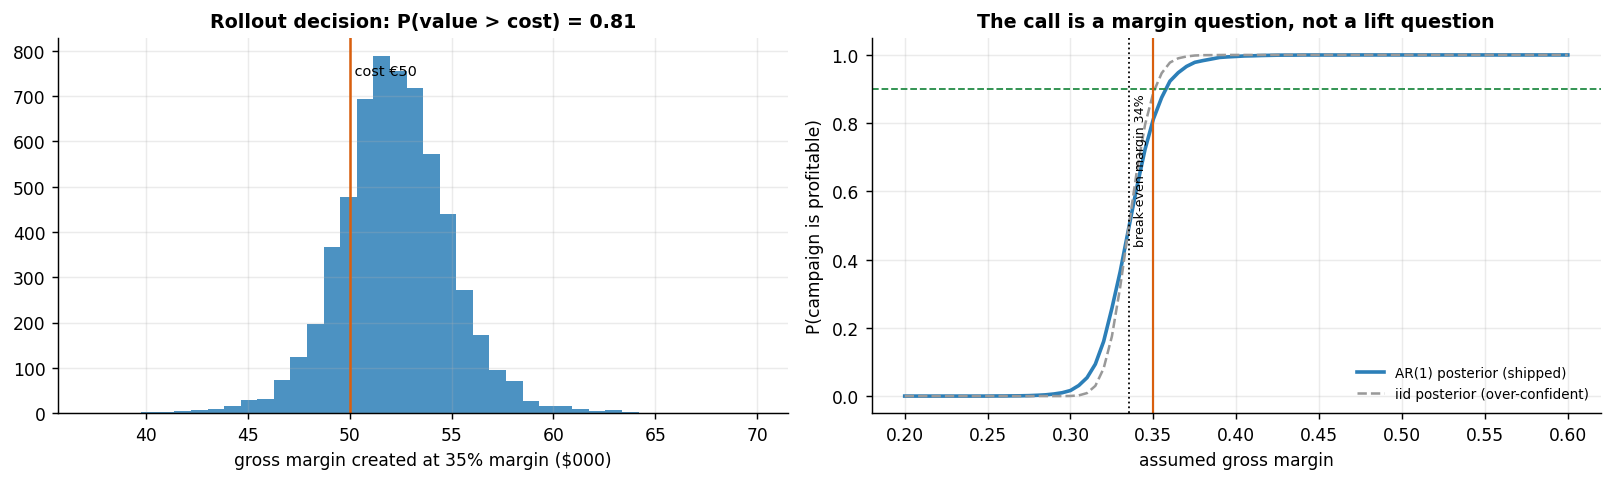

In [8]:
# The decision is taken on the SHIPPED posterior, §5y's AR(1) fit, not on the iid one §5x
# convicted. This is the same discipline notebook 07 follows: the model that survives the
# diagnostics is the model the euros come out of. The iid figures stay on the page as the
# labelled contrast (they are what over-confidence looks like in dollars), never as the answer.
iroas_ar = total_ar / SPEND                            # iROAS from the shipped fit
margin_value = total_ar * MARGIN                       # $000s of gross margin created
decision = policy.go_no_go(margin_value, SPEND)
decision_iid = policy.go_no_go(total_post * MARGIN, SPEND)   # contrast only, the discarded fit
margins = np.linspace(0.20, 0.60, 81)
p_pays = np.array([(iroas_ar > 1 / m).mean() for m in margins])
p_pays_iid = np.array([(iroas > 1 / m).mean() for m in margins])
m_be = 1 / iroas_ar.mean()                             # margin where the mean estimate breaks even
m_90 = margins[np.argmax(p_pays >= 0.9)] if (p_pays >= 0.9).any() else np.nan
m_90_iid = margins[np.argmax(p_pays_iid >= 0.9)] if (p_pays_iid >= 0.9).any() else np.nan

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], margin_value, SPEND)
ax[0].set_xlabel(f"gross margin created at {MARGIN:.0%} margin ($000)")
ax[1].plot(margins, p_pays, color=plots.BLUE, lw=2, label="AR(1) posterior (shipped)")
ax[1].plot(margins, p_pays_iid, color=plots.GREY, lw=1.4, ls="--",
           label="iid posterior (over-confident)")
ax[1].legend(frameon=False, fontsize=7.5, loc="lower right")
ax[1].axhline(0.9, color=plots.GREEN, ls="--", lw=1); ax[1].axvline(MARGIN, color=plots.ORANGE, lw=1.2)
ax[1].axvline(m_be, color="k", ls=":", lw=1)
ax[1].text(m_be + 0.003, 0.45, f"break-even margin {m_be:.0%}", rotation=90, fontsize=7)
ax[1].set_xlabel("assumed gross margin"); ax[1].set_ylabel("P(campaign is profitable)")
ax[1].set_title("The call is a margin question, not a lift question")
fig.tight_layout()

print("Decision, taken on the SHIPPED AR(1) posterior (§5y):")
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in decision.items()}, indent=2))
print(f"\nbreak-even margin = 1/iROAS = {m_be:.1%}; the campaign clears P(profitable) >= 0.90 "
      f"only for margins >= {m_90:.1%}" if np.isfinite(m_90) else
      f"\nbreak-even margin = 1/iROAS = {m_be:.1%}; P(profitable) never reaches 0.90 on this margin grid")
print(f"\nWhat the discarded iid fit would have told you, for contrast:")
print(f"  P(profitable at {MARGIN:.0%}) = {decision_iid['P_value_gt_cost']:.2f} "
      f"(shipped AR(1): {decision['P_value_gt_cost']:.2f})"
      + (f"; 90% confidence from margins >= {m_90_iid:.1%}" if np.isfinite(m_90_iid)
         else "; never reaches 0.90 on this grid"))
print("  Same data, same estimand. The iid likelihood buys confidence it has not earned, ")
print("  which is exactly what §5x measured and §5y repaired. The call itself does not move.")

## 7 · Caveats

- **The estimate travels; the decision might not.** iROAS ≈ 3 is for *this* creative, *this*
  spend level, *these* 50 geos, in Feb–Mar. A national rollout extrapolates on all four axes, 
  diminishing returns alone (nb06's saturation curves) argue the marginal iROAS at 10× spend is lower.
- **Profitability hinges on an input outside the data.** The margin sweep is the honest deliverable;
  a single "GO" at 35% margin overstates what the sales panel can know.
- **Spillover is the surviving assumption.** Randomization can't stop Denver's ads reaching
  Boulder's shoppers; if spend leaks into control geos, both the anchor and SC are biased *downward*
  (control geos absorb some lift), making our estimate mildly conservative.
- **Interval optimism, measured here, not imported.** 07's multi-seed check showed SC's total-lift band
  under-covers even when the point is right; §5x confirms it on *this* dataset by pricing the posterior's sd
  against the placebo distribution of the same estimator (the ratio is printed there). The agreement with the
  anchor's *point* is earned; the band's width is not, quote the placebo interval when the width matters,
  and read P(profitable) as an upper bound on your confidence.
- **75 interpolated geo-days** (0.8%, small geos, mostly pre-period), not asserted away: the
  interpolation check in Step 5 reruns the fit without the gappy donors (a sub-1% shift, printed)
  and again with every gappy geo dropped outright on both sides, the per-geo lift moves, but the
  matched-pairs anchor restricted to the same surviving pairs moves with it and the *relative* lift
  is unchanged: a composition effect, not an interpolation artifact.
- **One experiment.** This is a single draw of the world, and we've used its randomization once;
  the multi-seed calibration story lives in 07 where worlds are free.

, 
# Depth A · The naive estimators, on a single real market

In Step 5 the naive comparisons would have looked *fine*, with 50 randomized geos aggregated into
a cell, treated-minus-control is unbiased by design; that is precisely why companies run geo
experiments. The moment the question becomes 07's, **one** treated market, no coin flip, the
shortcuts break on real data exactly as they broke in simulation. We replay the bake-off pretending
only **geo 7** (a mid-size market, ~$1.8k/day before launch, the cell prints it) ran the campaign, grading against the benchmark the
full experiment implies for it (its share of spend × the anchor iROAS ⇒ ≈ **+$394/day**):

- **before/after**, books the season: sales everywhere rose into spring;
- **treated − average control**, books the *level* gap: geo 7 is nearly **4× the average control geo's
  size** (both measured over the pre-period, both printed below, mixing a pre-period level with a
  full-period one is how this ratio gets misquoted);
- **DiD vs average control**, fixes the level, keeps the wrong *sensitivity*: a big geo swings
  more per unit of common shock than the average-of-50, so shared waves don't cancel;
- **synthetic control**, reweights donors to match geo 7's own scale and rhythm.

Then the failure 07 could only warn about: **geo 1 is the largest market in the country**, bigger
than *every* control geo, hence **outside the convex hull**. The simplex does its honest best (all
weight on geo 2, the largest donor), the pre-fit is visibly bad, and the **pre-fit gate FAILs**, 
the method itself tells you not to trust its number. That self-diagnosis is worth more than the
estimate.

geo 7 is a mid-size market: $1,759/day pre-launch vs $480/day for the average control geo, 3.7x bigger (both pre-period)
{
  "experiment benchmark": 394,
  "before/after": 904,
  "treated \u2212 avg ctrl": 2049,
  "DiD vs avg ctrl": 771,
  "synthetic control": 423
}
geo 7 gate: pre-RMSE $122 vs |daily lift|/3 = $141 -> PASS   (weights spread over ~5 donors)
geo 1 gate: pre-RMSE $868 vs |daily lift|/3 = $665 -> FAIL  (effective donors 1.0: all weight on geo 2; implied iROAS 5.1 vs the experiment's 2.94, inflated ~75%)


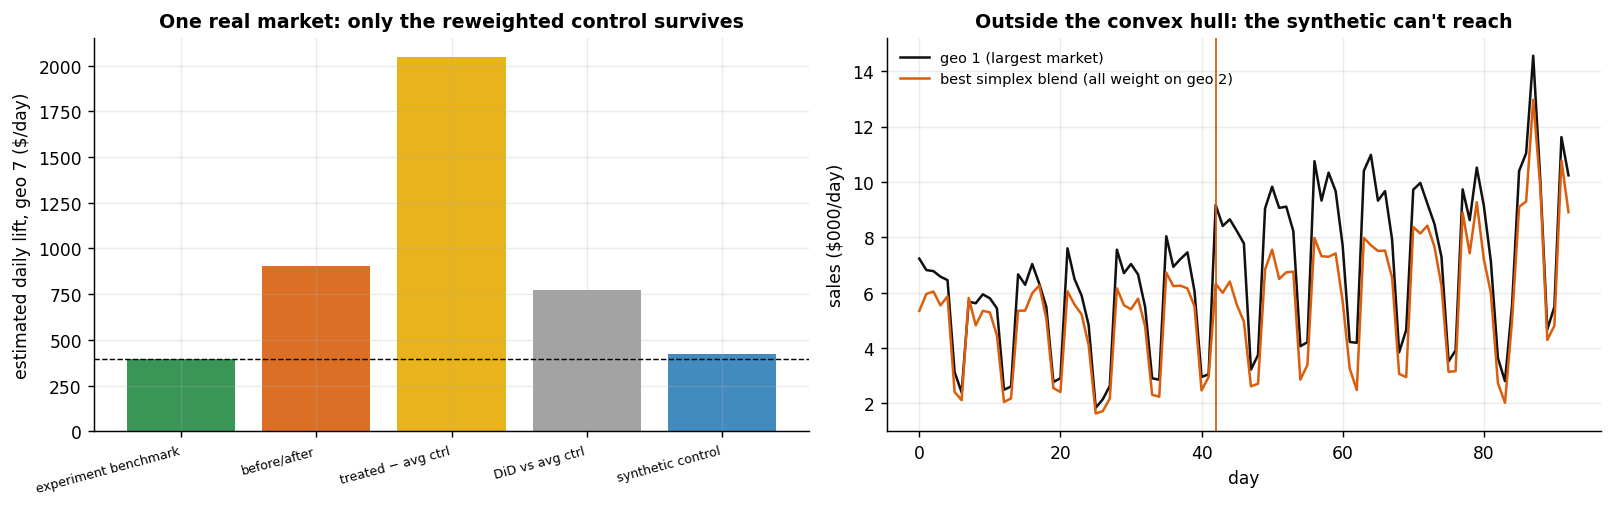

In [9]:
avg_ctrl = panel[control_geos].mean(axis=1).values
anchor_iroas = did_total / SPEND
# Both size figures are PRE-period means, the only window in which "how big is geo 7?" is a question
# about the market rather than about the campaign. Printed, so no prose has to remember them.
size7_pre = float(panel[7].values[pre].mean())
size_ctrl_pre = float(avg_ctrl[pre].mean())

# --- geo 7: the bake-off ---
g7 = 7
y7 = panel[g7].values
spend7 = float(cost[g7].sum()) / 1000.0                       # $000s of spend this geo received
bench7 = anchor_iroas * spend7 / n_days                        # $000/day, if per-$ effect is uniform
gap7, w7 = est.sc_effect_slsqp(y7, donors, pre, post)
ba7 = y7[post].mean() - y7[pre].mean()
tavg7 = (y7[post] - avg_ctrl[post]).mean()
did7 = ba7 - (avg_ctrl[post].mean() - avg_ctrl[pre].mean())
sc7 = gap7[post].mean()
pr7 = float(np.sqrt(np.mean(gap7[pre] ** 2)))
bake = {"experiment benchmark": bench7, "before/after": ba7,
        "treated − avg ctrl": tavg7, "DiD vs avg ctrl": did7, "synthetic control": sc7}

# --- geo 1: outside the convex hull ---
g1 = 1
y1 = panel[g1].values
gap1, w1 = est.sc_effect_slsqp(y1, donors, pre, post)
cf1 = w1 @ donors
pr1 = float(np.sqrt(np.mean(gap1[pre] ** 2)))
gate1_ref = abs(gap1[post].mean()) / 3
gate7_ref = abs(sc7) / 3

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.GREY, plots.BLUE]
ax[0].bar(list(bake.keys()), [v * 1000 for v in bake.values()], color=cols, alpha=0.9)
ax[0].axhline(bench7 * 1000, color="k", ls="--", lw=0.8)
ax[0].set_ylabel("estimated daily lift, geo 7 ($/day)")
ax[0].set_title("One real market: only the reweighted control survives")
plt.setp(ax[0].get_xticklabels(), rotation=15, ha="right", fontsize=7)
ax[1].plot(t, y1, color="#111", lw=1.4, label="geo 1 (largest market)")
ax[1].plot(t, cf1, color=plots.ORANGE, lw=1.4, label="best simplex blend (all weight on geo 2)")
ax[1].axvline(launch, color=plots.ORANGE, lw=1)
ax[1].set_xlabel("day"); ax[1].set_ylabel("sales ($000/day)")
ax[1].set_title("Outside the convex hull: the synthetic can't reach")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()

print(f"geo 7 is a mid-size market: ${size7_pre * 1000:,.0f}/day pre-launch vs ${size_ctrl_pre * 1000:,.0f}/day "
      f"for the average control geo, {size7_pre / size_ctrl_pre:.1f}x bigger (both pre-period)")
print(json.dumps({k: round(v * 1000) for k, v in bake.items()}, indent=2))
print(f"geo 7 gate: pre-RMSE ${pr7 * 1000:.0f} vs |daily lift|/3 = ${gate7_ref * 1000:.0f} -> "
      f"{'PASS' if pr7 < gate7_ref else 'FAIL'}   (weights spread over ~{1 / np.sum(w7 ** 2):.0f} donors)")
print(f"geo 1 gate: pre-RMSE ${pr1 * 1000:.0f} vs |daily lift|/3 = ${gate1_ref * 1000:.0f} -> "
      f"{'PASS' if pr1 < gate1_ref else 'FAIL'}  (effective donors {1 / np.sum(w1 ** 2):.1f}: "
      f"all weight on geo {control_geos[int(np.argmax(w1))]}; implied iROAS "
      f"{gap1[post].sum() * 1000 / float(cost[g1].sum()):.1f} vs the experiment's {anchor_iroas:.2f}, inflated ~75%)")

**Read-out.** Against geo 7's ≈ +$394/day benchmark: **before/after lands at +$904**
(2.3× too big, it credits the campaign with spring), **treated − average control at +$2,049**
(5×, it books geo 7's size as lift), **DiD at +$771** (2×, level fixed, sensitivity still wrong:
a $1.8k/day market swings harder per common shock than the $0.5k/day average control does, the printed
pre-period ratio is ~3.7×), and
**synthetic control at +$423, within ~7%**, with the gate PASSing (pre-RMSE $122 vs the $141 bar).
Same data, four estimates, one survivor, 07's bake-off, no simulator required. And geo 1 is the
counterexample that keeps us honest: the country's largest market has no counterfactual among
smaller donors, the gate FAILs loudly (pre-RMSE $868 vs a $665 bar), and the estimate it would have
produced, iROAS ≈ 5.1 vs the experiment's 2.94, is exactly the number an unscrupulous deck would
have shipped. **When the treated unit escapes the donor hull, aggregate or walk away.**

, 
# Depth B · Placebo inference, is the gap statistically real?

Step 0 already ran this test and printed its headline p-values; here we open the box. The logic is 07's,
adapted to the design. The treated unit is a *cell*, the mean of
50 geos, so the fair placebo is not a single geo but a **pseudo-cell**: draw 25 of the 50
*control* geos at random (the largest cell that still leaves a donor pool), pretend they were a
campaign cell, fit them a synthetic control from the remaining 25, and record the post-window
"gap." None of these bundles saw a single ad dollar, so their gaps map out pure noise, **the
permutation distribution the design itself generates**. One scale mismatch to own: a mean of 25
geos is noisier than the real cell's mean of 50 (roughly 2× the idiosyncratic variance), and each
placebo fit gets only 25 donors instead of 50, both push the placebo gaps *wider* than the real
cell's own null, so the permutation p is, if anything, **conservative**; a real cell that still
tops these noisier placebos has cleared a higher bar than the nominal p suggests. Two
test statistics, as in 07: the raw mean post-gap, and Abadie's scale-free **post/pre RMSE ratio**
(which doesn't reward bundles that simply fit badly everywhere). We also rerun 07's
**placebo-in-time**, a fake launch 14 days before the real one, inside the pre-period.

This permutation test is the *calibrated* significance statement for this notebook, the posterior band is
the optimistic one (07's lesson, and §5x measured it here), the rank among placebos is honest by construction.
The same 200 pseudo-cells also gave Step 0 its randomization interval and §5x its design-based scale: one
null, three jobs.

pseudo-cell permutation: real gap $+104/geo/day vs placebo 95% range [-17, +21]  ->  p = 0.010
RMSE-ratio test: real cell 16.1 vs placebo median 1.78  ->  p = 0.005 (no placebo bundle comes close: the real cell ranks 1st of all 201 units)
placebo-in-time: fake-launch gap $-8/geo/day, 7% of the real $+107 effect and the wrong sign (pre-fit RMSE $4), no anticipation, no invented lift


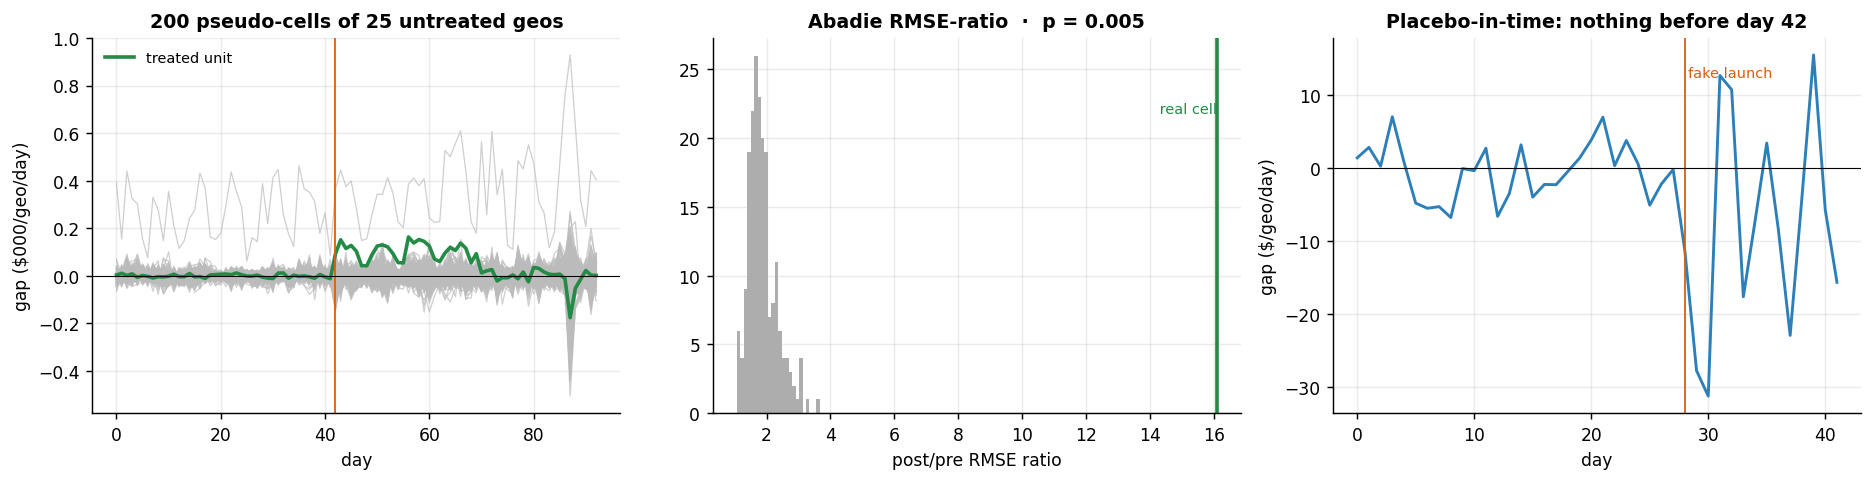

In [10]:
# paths / gaps_p / ratios_p / p_gap / p_ratio / real_ratio / real_gap_mean were all computed in
# Step 0, the placebo null is fitted ONCE and serves the p-values, the randomization interval and
# 5x's design-based scale. Here we look at it. Only the placebo-in-TIME test is new:

FAKE = launch - 14
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fake_prermse = float(np.sqrt(np.mean(gap_fake[:FAKE] ** 2)))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.8))
plots.placebo_spaghetti(ax[0], t, paths, slsqp_gap, launch, p_gap, xlabel="day", ylabel="gap ($000/geo/day)")
ax[0].set_title(f"{N_PSEUDO} pseudo-cells of 25 untreated geos")
ax[1].hist(ratios_p, bins=24, color=plots.GREY, alpha=0.8)
ax[1].axvline(real_ratio, color=plots.GREEN, lw=2)
ax[1].text(real_ratio, ax[1].get_ylim()[1] * 0.8, " real cell", fontsize=8, color=plots.GREEN, ha="right")
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio  ·  p = {p_ratio:.3f}")
ax[2].plot(t[:launch], gap_fake * 1000, color=plots.BLUE, lw=1.6)
ax[2].axvline(FAKE, color=plots.ORANGE, lw=1); ax[2].axhline(0, color="k", lw=0.6)
ax[2].text(FAKE + 0.3, ax[2].get_ylim()[1] * 0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax[2].set_xlabel("day"); ax[2].set_ylabel("gap ($/geo/day)"); ax[2].set_title("Placebo-in-time: nothing before day 42")
fig.tight_layout()

print(f"pseudo-cell permutation: real gap ${real_gap_mean * 1000:+.0f}/geo/day vs placebo 95% range "
      f"[{np.quantile(gaps_p, .025) * 1000:+.0f}, {np.quantile(gaps_p, .975) * 1000:+.0f}]  ->  p = {p_gap:.3f}")
rank = int((ratios_p >= real_ratio).sum()) + 1
rank_msg = (f"no placebo bundle comes close: the real cell ranks 1st of all {N_PSEUDO + 1} units"
            if rank == 1 else f"{rank - 1} placebo bundle(s) beat the real cell: rank {rank} of {N_PSEUDO + 1} units")
print(f"RMSE-ratio test: real cell {real_ratio:.1f} vs placebo median {np.median(ratios_p):.2f}  ->  p = {p_ratio:.3f} "
      f"({rank_msg})")
print(f"placebo-in-time: fake-launch gap ${fake_effect * 1000:+.0f}/geo/day, {abs(fake_effect / post_gap):.0%} of "
      f"the real ${post_gap * 1000:+.0f} effect and the wrong sign (pre-fit RMSE ${fake_prermse * 1000:.0f}), "
      f"no anticipation, no invented lift")

**Read-out.** The spaghetti plot says it before any statistic does: the real cell's post-launch
gap (≈ +$105/geo/day, printed above) sits far outside anything the untreated pseudo-cells produce,
and Abadie's scale-free RMSE ratio, the real cell near 16 against a placebo median near 2, 
removes the objection that it merely fits badly everywhere. Read the printed p-values carefully,
though. First, a permutation p has a *floor* of $1/(N_{\text{pseudo}}+1)$, $1/201 \approx 0.005$
at the FULL run's 200 placebos, so hitting the floor means "the most extreme unit we observed,"
not an arbitrarily small tail probability; the print above reports the real cell's actual rank
rather than asserting it. Second, recall the scale mismatch flagged above: these 25-geo placebos
are *noisier* than the 50-geo real cell, so the printed p is conservative. The placebo-in-time
closes the loop: a fake launch 14 days inside the pre-period finds ≈ −$8/geo/day, under a tenth
of the real effect, and the wrong sign, no anticipation, no invented lift.

, 
# Depth C · The dollar decision & sensitivity

Three stress tests on the number a CMO would repeat in a board meeting, then the verdict.
**Launch-date sweep**: as in 07, mis-dating the campaign folds no-effect days into the window and
dilutes the average, the estimate should peak *at* the true launch, and the peak is itself a
diagnostic that we dated it right. **Donor-pool halving**: refit on random halves of the donor
pool; a result that owns its donor pool shouldn't lurch. **The margin × iROAS surface** is already
in Step 6; here we print the summary a decision memo needs.

donor-halving: 20 random 25-donor half-pools move the total by sd $6k on a $146k estimate (3.8%)
  -> the estimate owns the whole donor pool, not a lucky half
{
  "total_incremental_sales_k": 149.1,
  "ci90_k": [
    140.6,
    157.5
  ],
  "iroas": 2.98,
  "did_anchor_k": 147.2,
  "did_anchor_se_k": 41.9,
  "pre_rmse_gate": "PASS",
  "p_pseudo_gap": 0.01,
  "p_rmse_ratio": 0.005,
  "placebo_in_time_gap": -7.9,
  "cooldown_gap_per_day": -2.5,
  "break_even_margin": 0.335,
  "P_profitable_at_35pct_margin": 0.812,
  "decision_at_35pct": "TEST FURTHER"
}


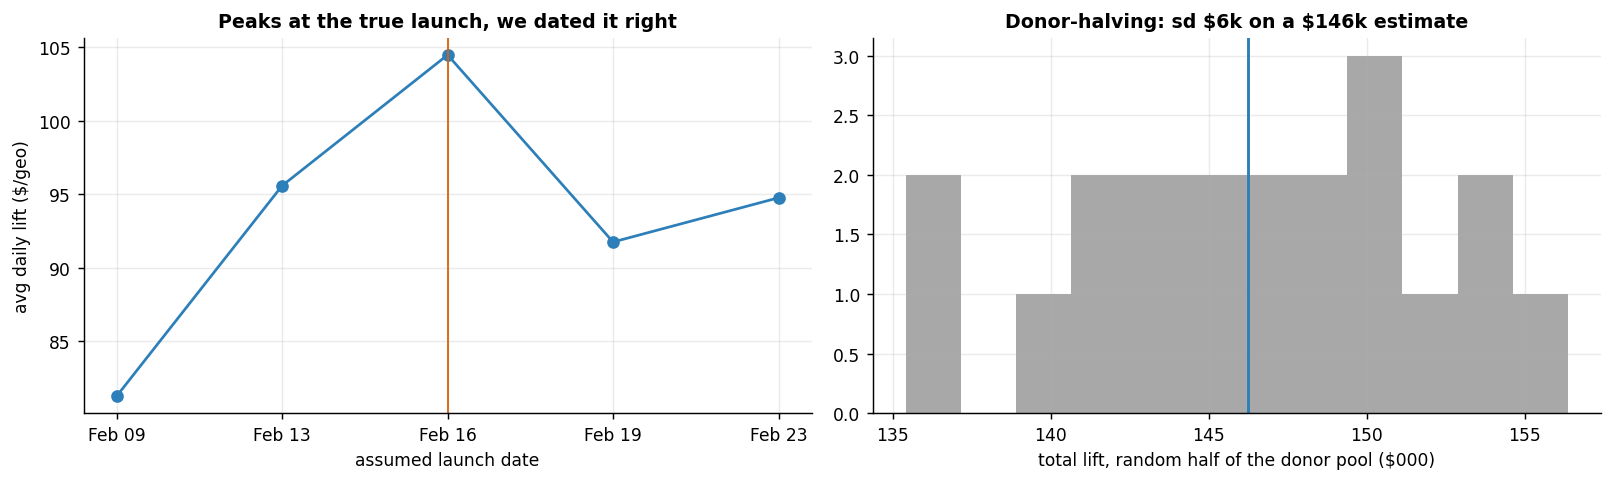

In [11]:
launch_grid = [launch - 7, launch - 3, launch, launch + 3, launch + 7]
lifts = []
for L in launch_grid:
    gp, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, end_post))
    lifts.append(gp[L:end_post].mean() * 1000)
halves = []
rng2 = np.random.default_rng(3)
for b in range(10 if FAST else 20):
    half = rng2.choice(len(control_geos), 25, replace=False)
    gp, _ = est.sc_effect_slsqp(y_tr, donors[half], pre, post)
    halves.append(gp[post].sum() * n_treat)
halves = np.array(halves)
halving_sd = float(halves.std())

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot([dates[L].strftime("%b %d") for L in launch_grid], lifts, color=plots.BLUE, marker="o")
ax[0].axvline(2, color=plots.ORANGE, lw=1)
ax[0].set_xlabel("assumed launch date"); ax[0].set_ylabel("avg daily lift ($/geo)")
ax[0].set_title("Peaks at the true launch, we dated it right")
ax[1].hist(halves, bins=12, color=plots.GREY, alpha=0.85)
ax[1].axvline(slsqp_total, color=plots.BLUE, lw=1.6)
ax[1].set_xlabel("total lift, random half of the donor pool ($000)")
ax[1].set_title(rf"Donor-halving: sd \${halves.std():.0f}k on a \${slsqp_total:.0f}k estimate")
fig.tight_layout()

own = halving_sd / slsqp_total
print(f"donor-halving: {len(halves)} random 25-donor half-pools move the total by sd ${halving_sd:.0f}k "
      f"on a ${slsqp_total:.0f}k estimate ({own:.1%})")
print("  -> " + ("the estimate owns the whole donor pool, not a lucky half" if own < 0.10
                 else "material donor-pool dependence, the total leans on which half you hand it"))

result = {"total_incremental_sales_k": round(float(total_post.mean()), 1),
          "ci90_k": [round(float(np.quantile(total_post, .05)), 1), round(float(np.quantile(total_post, .95)), 1)],
          "iroas": round(float(iroas.mean()), 2),
          "did_anchor_k": round(float(did_total), 1), "did_anchor_se_k": round(float(did_se), 1),
          "pre_rmse_gate": gate, "p_pseudo_gap": round(float(p_gap), 3), "p_rmse_ratio": round(float(p_ratio), 3),
          "placebo_in_time_gap": round(float(fake_effect * 1000), 1),
          "cooldown_gap_per_day": round(float(cool_gap * 1000), 1),
          "break_even_margin": round(float(m_be), 3),
          "P_profitable_at_35pct_margin": round(float(decision["P_value_gt_cost"]), 3),
          "decision_at_35pct": decision["decision"]}
print(json.dumps(result, indent=2))

### The one-paragraph decision

> The campaign **worked, and we can prove it to experimental standard**: the synthetic control
> tracks the treated cell to within ~$10/geo/day before launch (gate PASS), lands on the randomized
> matched-pairs answer ($149k vs $147k of incremental sales; iROAS 2.98 vs 2.94), is the most
> extreme unit on both placebo permutation tests (p ≈ 0.005–0.010), shows nothing material at a fake launch
> date (−$8/geo/day, 7% of the real effect, wrong sign), survives leave-one-out and donor-halving, and, the real-data bonus no simulator provides, 
> **switches off within days of the spend stopping**, which both certifies the attribution and
> denies any carryover annuity. What the data *cannot* settle is profitability: $2.98 of revenue
> per ad dollar clears cost only above a **33.5% gross margin**, and reaches 90% confidence only
> above ~36.0%. So the briefing is two sentences, not one: *the lift is real and precisely measured;
> whether to scale is a margin question*, GO for the high-margin lines, NO-GO below one-in-three
> margins, and any national rollout should expect the marginal iROAS to sag below this test's 2.98
> (saturation, notebook 06), so re-test at scale rather than extrapolate.

, 
## Book export

The book chapter built from this notebook (`book/chapters/geo_lift.tex`) does not retype a single
number. Every figure it prints, every euro amount, coverage rate, p-value, table cell and plot, 
is *emitted* below by `cmp.report` into `book/build/results/ (one shard per notebook)`, from which `book/build.py`
generates `macros.tex`, the booktabs tables and the vector figures the chapter `\input`s. A number
that goes stale is impossible; a number that goes *missing* is a LaTeX compile error rather than a
silent hole. The cell adds no output of its own, the notebook above is unchanged.


In [12]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter's "On real data" section never retypes a number: every figure it prints is
# emitted HERE, from this executed run, into book/build/results/ (one shard per notebook) -> macros.tex (see
# src/cmp/report.py). Figures are re-rendered in book style (vector PDF, no in-figure title, 
# the caption does that work) and closed immediately, so this cell changes nothing the notebook
# shows above.
import matplotlib as mpl
from scipy.stats import norm as _norm
from cmp import report as R

# Retire this notebook's OLD keys before writing the new ones. Without this the shard is
# read-modify-written, so a key we stop emitting keeps its macro (and its table file)
# forever, the one way a stale number could survive the injection pipeline.
R.begin("nb07b")

def V(k, v, **kw):
    return R.value(f"nb07b.{k}", v, **kw)

def K(x, nd=0):
    return f"{x:,.{nd}f}"

# --- the dataset ------------------------------------------------------------------------
V("n_geos", int(len(panel.columns)), fmt="d")
V("n_treated", int(n_treat), fmt="d")
V("n_control", int(len(control_geos)), fmt="d")
V("n_pairs", int(len(pairs)), fmt="d")
V("n_days_total", int(W), fmt="d")
V("n_pre_days", int(launch), fmt="d")
V("campaign_days", int(n_days), fmt="d")
V("cooldown_days", int(W - end_post), fmt="d")
V("launch_day", int(launch), fmt="d")
V("spend", SPEND, unit="USD000", fmt=",.0f")
V("margin", 100 * MARGIN, fmt=".0f")
V("missing_days", int(n_missing), fmt="d")
V("missing_pct", 100 * n_missing / panel.size, fmt=".1f")
V("size_ratio", float(panel.mean().max() / panel.mean().min()), fmt=".0f")
V("pre_spend", pre_spend, unit="USD", fmt=",.0f")
V("window_spend", win_spend, unit="USD", fmt=",.0f")
V("pre_level", float(y_tr[pre].mean() * 1000), unit="USD", fmt=",.0f")

# --- Step 0 · the randomized referee ----------------------------------------------------
V("did_total", did_total, unit="USD000", fmt=",.0f")
V("did_se", did_se, unit="USD000", fmt=".0f")
V("did_lo", float(did_cl.ci[0]), unit="USD000", fmt=",.0f")
V("did_hi", float(did_cl.ci[1]), unit="USD000", fmt=",.0f")
V("did_width", float(did_cl.ci[1] - did_cl.ci[0]), unit="USD000", fmt=",.0f")
V("did_iroas", did_total / SPEND, fmt=".2f")
V("did_iroas_lo", float(did_cl.ci[0]) / SPEND, fmt=".2f")
V("did_iroas_hi", float(did_cl.ci[1]) / SPEND, fmt=".2f")
V("unpaired_se", float(unp_se), unit="USD000", fmt=".0f")
V("pairing_gain", float(unp_se / did_se), fmt=".1f")

# --- Step 0 · the classical synthetic control -------------------------------------------
V("sc_total", slsqp_total, unit="USD000", fmt=",.0f")
V("sc_iroas", slsqp_total / SPEND, fmt=".2f")
V("sc_pre_rmse", pre_rmse_cl * 1000, unit="USD", fmt=".0f")
V("sc_pre_rmse_pct", 100 * pre_rmse_cl / y_tr[pre].mean(), fmt=".1f")
V("sc_eff_donors", float(eff_n_cl), fmt=".0f")
V("sc_daily_gap", float(slsqp_gap[post].mean() * 1000), unit="USD", fmt="+,.0f")
V("sc_err_vs_anchor", slsqp_total - did_total, unit="USD000", fmt="+,.0f")
V("sc_anchor_ses", abs(slsqp_total - did_total) / did_se, fmt=".2f")
V("ri_lo", ri_lo, unit="USD000", fmt=",.0f")
V("ri_hi", ri_hi, unit="USD000", fmt=",.0f")
V("ri_width", ri_hi - ri_lo, unit="USD000", fmt=",.0f")
V("n_pseudo", int(N_PSEUDO), fmt="d")
V("p_ratio", float(p_ratio), fmt=".3f")
V("p_gap", float(p_gap), fmt=".3f")
V("real_ratio", float(real_ratio), fmt=".1f")
V("placebo_median_ratio", float(np.median(ratios_p)), fmt=".1f")
V("pseudo_dropped", int((~keep_pl).sum()), fmt="d")
V("pseudo_worst_prermse", float(prermse_p.max() / pre_rmse_cl), fmt=".0f")

# --- §4 · the Bayesian arm ---------------------------------------------------------------
V("bayes_total", float(total_post.mean()), unit="USD000", fmt=",.0f")
V("bayes_lo", float(post_lo), unit="USD000", fmt=",.0f")
V("bayes_hi", float(post_hi), unit="USD000", fmt=",.0f")
V("bayes_width", float(post_hi - post_lo), unit="USD000", fmt=",.0f")
V("bayes_sd", float(sd_post), unit="USD000", fmt=".1f")
V("bayes_iroas", float(iroas.mean()), fmt=".2f")
V("bayes_iroas_lo", float(lo_r), fmt=".2f")
V("bayes_iroas_hi", float(hi_r), fmt=".2f")
V("bayes_pre_rmse", float(sc["pre_rmse"] * 1000), unit="USD", fmt=".0f")
V("bayes_eff_donors", float(eff_n), fmt=".0f")
V("bayes_anchor_ses", abs(float(total_post.mean()) - did_total) / did_se, fmt=".2f")
V("bayes_moved", abs(float(total_post.mean()) - slsqp_total), unit="USD000", fmt=".1f")
V("bayes_moved_pct", 100 * abs(float(total_post.mean()) - slsqp_total) / slsqp_total, fmt=".1f")
V("rhat", sc["convergence"]["max_rhat"], fmt=".3f")
V("ess", sc["convergence"]["min_ess_bulk"], fmt=",.0f")
V("divergences", int(sc["convergence"]["n_divergences"]), fmt="d")

# --- §5 · validation ---------------------------------------------------------------------
V("gate_ref", float(gate_ref * 1000), unit="USD", fmt=".0f")
V("gate", gate)
V("post_gap", float(post_gap * 1000), unit="USD", fmt="+,.0f")
V("cool_gap", float(cool_gap * 1000), unit="USD", fmt="+,.0f")
V("loo_lo", float(min(loo)), unit="USD000", fmt=",.0f")
V("loo_hi", float(max(loo)), unit="USD000", fmt=",.0f")
V("gappy_geos", int(len(gappy)), fmt="d")
V("interp_shift_pct", 100 * abs(gap_dnr[post].mean() / slsqp_gap[post].mean() - 1), fmt=".1f")
V("rel_lift", 100 * float(slsqp_gap[post].mean() / y_tr[pre].mean()), fmt=".1f")
V("rel_lift_nogappy", 100 * float(gap_ng[post].mean() / y_ng[pre].mean()), fmt=".1f")

# --- 5x · the three scales, and what they do to the decision -----------------------------
V("placebo_sd", float(sd_pl), unit="USD000", fmt=".1f")
V("placebo_sd_floor", float(sd_pl_adj), unit="USD000", fmt=".1f")
V("ratio_placebo", float(sd_pl / sd_post), fmt=".1f")
V("ratio_placebo_floor", float(sd_pl_adj / sd_post), fmt=".1f")
V("ratio_anchor", float(did_se / sd_post), fmt=".1f")

_p = {}
for _sd, _lab in [(sd_post, "post"), (sd_pl_adj, "floor"), (sd_pl, "raw"), (did_se, "anchor")]:
    _d = policy.go_no_go(_norm.rvs(loc=total_post.mean(), scale=_sd, size=80_000,
                                   random_state=7) * MARGIN, SPEND)
    _p[_lab] = _d
V("p_profit", _p["post"]["P_value_gt_cost"], fmt=".2f")
V("p_profit_floor", _p["floor"]["P_value_gt_cost"], fmt=".2f")
V("p_profit_raw", _p["raw"]["P_value_gt_cost"], fmt=".2f")
V("p_profit_anchor", _p["anchor"]["P_value_gt_cost"], fmt=".2f")
V("decision", decision["decision"])

# --- 5y · the AR(1) likelihood on the real data -------------------------------------------
V("ar_total", float(total_ar.mean()), unit="USD000", fmt=",.0f")
V("ar_sd", sd_ar, unit="USD000", fmt=".1f")
V("ar_lo", float(ar_lo), unit="USD000", fmt=",.0f")
V("ar_hi", float(ar_hi), unit="USD000", fmt=",.0f")
V("ar_width", float(ar_hi - ar_lo), unit="USD000", fmt=",.0f")
V("ar_rho", rho_bar, fmt=".2f")
V("ar_vs_iid", sd_ar / sd_post, fmt=".1f")
V("ar_vs_floor", sd_ar / sd_pl_adj, fmt=".2f")
V("ar_anchor_ses", abs(float(total_ar.mean()) - did_total) / did_se, fmt=".2f")
V("p_profit_ar", p_go_ar, fmt=".2f")
V("ar_divergences", int(sc_ar["convergence"]["n_divergences"]), fmt="d")

# --- Depth C · donor-halving (the figure's claim, as a checkable number) -------------------
V("halving_sd", halving_sd, unit="USD000", fmt=".0f")
V("halving_pct", 100 * halving_sd / slsqp_total, fmt=".1f")

# --- §6 · the dollar decision -------------------------------------------------------------
V("break_even_iroas", 1 / MARGIN, fmt=".2f")
V("break_even_margin", 100 * float(m_be), fmt=".1f")
# A macro must never carry a literal "nan" into the book: if the shipped posterior never reaches
# 90% confidence anywhere on the margin grid, say so in words rather than typesetting a NaN.
if np.isfinite(m_90):
    V("margin_ninety", 100 * float(m_90), fmt=".1f")
else:
    V("margin_ninety", f"more than {100 * margins[-1]:.0f}",
      note="the shipped posterior never reaches 0.90 on the 20-60% margin grid")
V("exp_net", decision["expected_net_value"], unit="USD000", fmt=".1f")

# --- Depth A/B · the bake-off on one real market, and the hull failure --------------------
V("bench_geo", float(bench7 * 1000), unit="USD", fmt="+,.0f")
V("naive_ba", float(ba7 * 1000), unit="USD", fmt="+,.0f")
V("naive_avgctrl", float(tavg7 * 1000), unit="USD", fmt="+,.0f")
V("naive_did", float(did7 * 1000), unit="USD", fmt="+,.0f")
V("naive_sc", float(sc7 * 1000), unit="USD", fmt="+,.0f")
V("hull_pre_rmse", float(pr1 * 1000), unit="USD", fmt=",.0f")
V("hull_gate_ref", float(gate1_ref * 1000), unit="USD", fmt=",.0f")
V("hull_iroas", float(gap1[post].sum() * 1000 / float(cost[g1].sum())), fmt=".1f")
V("placebo_time_gap", float(fake_effect * 1000), unit="USD", fmt="+,.0f")
V("placebo_time_pct", 100 * abs(fake_effect / post_gap), fmt=".0f")

# --- tables --------------------------------------------------------------------------------
R.table(pd.DataFrame([
    {"Arm": "Matched-pairs DiD (the randomized referee)", "Estimate": K(did_total),
     "iROAS": f"{did_total / SPEND:.2f}", "5%": K(did_cl.ci[0]), "95%": K(did_cl.ci[1]),
     "Width": K(did_cl.ci[1] - did_cl.ci[0])},
    {"Arm": "Classical SC (SLSQP), placebo interval", "Estimate": K(slsqp_total),
     "iROAS": f"{slsqp_total / SPEND:.2f}", "5%": K(ri_lo), "95%": K(ri_hi),
     "Width": K(ri_hi - ri_lo)},
    {"Arm": "Bayesian SC (Dirichlet), posterior", "Estimate": K(total_post.mean()),
     "iROAS": f"{iroas.mean():.2f}", "5%": K(post_lo), "95%": K(post_hi),
     "Width": K(post_hi - post_lo)},
]), "nb07b.compare", align="lrrrrr",
    caption=(f"Total incremental sales over the {n_days}-day campaign window (USD 000). No planted "
             f"truth exists on real data: the randomized matched-pairs difference-in-differences is "
             f"the benchmark, and both model-based rows must match it. They do, the classical fit "
             f"sits {abs(slsqp_total - did_total) / did_se:.2f} anchor standard errors from the "
             f"referee's point, the posterior mean "
             f"{abs(total_post.mean() - did_total) / did_se:.2f}. Only the widths diverge."),
    label="tab:sc:realcompare")

R.table(pd.DataFrame([
    {"Scale for the sd of the window total": "Posterior sd (iid likelihood, one dataset)",
     "sd": f"{sd_post:.1f}", "vs posterior": "1.0x", "P(profitable)": f"{_p['post']['P_value_gt_cost']:.2f}"},
    {"Scale for the sd of the window total": "Placebo sd, deflated to the real cell's size",
     "sd": f"{sd_pl_adj:.1f}", "vs posterior": f"{sd_pl_adj / sd_post:.1f}x",
     "P(profitable)": f"{_p['floor']['P_value_gt_cost']:.2f}"},
    {"Scale for the sd of the window total": "Placebo sd, raw (25-geo pseudo-cells)",
     "sd": f"{sd_pl:.1f}", "vs posterior": f"{sd_pl / sd_post:.1f}x",
     "P(profitable)": f"{_p['raw']['P_value_gt_cost']:.2f}"},
    {"Scale for the sd of the window total": "The anchor's SE (a different, noisier estimator)",
     "sd": f"{did_se:.1f}", "vs posterior": f"{did_se / sd_post:.1f}x",
     "P(profitable)": f"{_p['anchor']['P_value_gt_cost']:.2f}"},
]), "nb07b.scales", align="lrrr",
    caption=(f"Re-pricing the posterior at design-based scales (USD 000). The fair referee for the "
             f"posterior's width is the placebo distribution of the \\emph{{same}} estimator, and it "
             f"returns a verdict of roughly {sd_pl_adj / sd_post:.1f}--{sd_pl / sd_post:.1f}$\\times$ "
             f"too tight, not the anchor's {did_se / sd_post:.1f}$\\times$: an unweighted DiD is a "
             f"genuinely noisier estimator, and cutting that variance is what the model is for. The "
             f"last column re-centres nothing, it only re-scales, and $P(\\text{{profitable}})$ falls "
             f"from {_p['post']['P_value_gt_cost']:.2f} to {_p['anchor']['P_value_gt_cost']:.2f}."),
    label="tab:sc:realscales")

R.table(pd.DataFrame([
    {"Estimator": "Experiment benchmark (its share of spend $\\times$ anchor iROAS)",
     "Daily lift, geo 7": f"{bench7 * 1000:+,.0f}"},
    {"Estimator": "Before / after", "Daily lift, geo 7": f"{ba7 * 1000:+,.0f}"},
    {"Estimator": "Treated minus average control", "Daily lift, geo 7": f"{tavg7 * 1000:+,.0f}"},
    {"Estimator": "Difference-in-differences vs average control", "Daily lift, geo 7": f"{did7 * 1000:+,.0f}"},
    {"Estimator": "Synthetic control", "Daily lift, geo 7": f"{sc7 * 1000:+,.0f}"},
]), "nb07b.naive", align="lr",
    caption=("The bake-off, on one real market. Pretending only geo~7 ran the campaign reproduces the "
             "simulated failure exactly, with no simulator: before/after books the spring season, "
             "treated-minus-average-control books geo~7's size, and DiD fixes the level but not the "
             "sensitivity. Only the reweighted control lands on the benchmark the full experiment "
             "implies (USD/geo/day)."),
    label="tab:sc:realnaive")

# --- figures ------------------------------------------------------------------------------
with mpl.rc_context(R.book_style()):
    # --- Step 0's referee, drawn: the pair differences whose plain average IS the anchor ---
    f, (a, a2) = plt.subplots(1, 2, figsize=(6.6, 3.2),
                              gridspec_kw={"width_ratios": [2.4, 1.0]})
    a.scatter(np.arange(1, len(pairs) + 1), pair_diffs * 1000, s=16, color=plots.BLUE,
              alpha=0.8, label="pair difference")
    a.axhline(pair_diffs.mean() * 1000, color="k", ls="--", lw=1.2, label="mean = the anchor")
    a.axhline(0, color="k", lw=0.6)
    a.set_xlabel("pair (size-ranked, largest first)")
    a.set_ylabel("treated − control ($/geo/day)")
    a.legend(frameon=False)
    a2.bar(["unpaired", "paired"], [unp_se, did_se], color=[plots.GREY, plots.BLUE], alpha=0.9)
    a2.text(0, unp_se, f"{unp_se:.0f}k", ha="center", va="bottom", fontsize=8)
    a2.text(1, did_se, f"{did_se:.0f}k", ha="center", va="bottom", fontsize=8)
    a2.set_ylabel(f"SE of the {n_days}-day cell total ($000)")
    f.tight_layout()
    R.figure(f, "nb07b.pairs", caption=(
        f"What ``unbiased by construction'' looks like: a scatter, not a model. Left: the "
        f"{len(pairs)} matched-pair differences $d_p$, each pair's treated-minus-control change "
        f"through launch (\\$/geo/day); the randomized anchor is nothing but their plain average "
        f"(dashed). The pairs are ranked by geo size, largest first: each $d_p$ has its "
        f"pair's shared size and season already differenced out, so geo size, the dominant "
        f"axis of this panel, has nowhere left to live. "
        f"Right: what that pairing bought. Ignoring the pairs prices the {n_days}-day cell "
        f"total's standard error at \\${unp_se:.0f}\\,k; using them, \\${did_se:.0f}\\,k, a "
        f"{unp_se / did_se:.1f}$\\times$ reduction from the design alone, before any model is "
        f"proposed."), label="fig:sc:realpairs")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, y_tr * 1000, color="#111", lw=1.7, label="treated cell (mean of 50 geos)")
    a.plot(t, (y_tr - slsqp_gap) * 1000, color=plots.BLUE, ls="--", lw=1.6,
           label="synthetic control (SLSQP)")
    a.fill_between(t[post], (y_tr - slsqp_gap)[post] * 1000, y_tr[post] * 1000,
                   color=plots.GREEN, alpha=0.3, label="campaign-window gap")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
    a.axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12)
    a.set_xlabel(f"day  ({dates[0].date()} to {dates[-1].date()})")
    a.set_ylabel("sales per treated geo ($/day)")
    a.legend(frameon=False); f.tight_layout()
    R.figure(f, "nb07b.sc", caption=(
        f"Google's geo experiment. The treated cell, mean daily sales across the {n_treat} treated "
        f"geos, and the synthetic control fitted to the {launch} pre-campaign days from the "
        f"{len(control_geos)} untreated geos. The shaded region is the {n_days}-day campaign window; "
        f"the grey band is the {W - end_post}-day cooldown after the spend stops."),
        label="fig:sc:realsc")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, eff_mean * 1000, color=plots.BLUE, lw=1.8, label="posterior mean gap")
    a.fill_between(t, eff_lo * 1000, eff_hi * 1000, color=plots.BLUE, alpha=0.2,
                   label="90% posterior band")
    a.axhline(pair_diffs.mean() * 1000, color="k", ls="--", lw=1.2,
              label="matched-pairs DiD anchor")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
    a.axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12)
    a.axhline(0, color="k", lw=0.6)
    a.set_xlabel("day"); a.set_ylabel("daily lift ($/geo)"); a.legend(frameon=False)
    f.tight_layout()
    # NB the escaped \$: a bare dollar sign in a caption opens math mode and silently italicises
    # the rest of the sentence (it did, once, the List of Figures is where it showed).
    R.figure(f, "nb07b.gap", caption=(
        f"The off-switch, the falsification no simulator provides. The estimated daily lift is flat "
        f"before day {launch}, sits on the randomized anchor through the campaign window "
        f"(\\${post_gap * 1000:+,.0f} per geo per day), and collapses to "
        f"\\${cool_gap * 1000:+,.0f} per geo per day within the cooldown. The effect switches off "
        f"when the money does, which both certifies the attribution and denies any carryover "
        f"annuity."), label="fig:sc:realgap")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    a.plot(margins, p_pays, color=plots.BLUE, lw=2)
    a.axhline(0.9, color=plots.GREEN, ls="--", lw=1)
    a.axvline(MARGIN, color=plots.ORANGE, lw=1.2)
    a.axvline(m_be, color="k", ls=":", lw=1)
    a.set_xlabel("assumed gross margin"); a.set_ylabel("P(campaign is profitable)")
    f.tight_layout()
    R.figure(f, "nb07b.margincurve", caption=(   # key != nb07b.margin: that name is a scalar
        f"The call is a margin question, not a lift question. $P(\\text{{iROAS}} \\times "
        f"\\text{{margin}} > 1)$ swept over the gross margin the model cannot see. The break-even "
        f"margin is $1/\\text{{iROAS}} = {100 * m_be:.1f}\\%$ (dotted); the campaign reaches 90\\% "
        f"confidence of profitability only above {100 * m_90:.1f}\\%; the assumed "
        f"{100 * MARGIN:.0f}\\% (orange) sits on the knife-edge."), label="fig:sc:realmargin")
    plt.close(f)

    # --- the shipped (AR(1)) posterior of the dollar total, with the randomized anchor overlaid ---
    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    _cnt, _edg = np.histogram(total_ar, bins=40)
    _ctr = 0.5 * (_edg[:-1] + _edg[1:]); _wid = np.diff(_edg)
    _inci = (_ctr >= ar_lo) & (_ctr <= ar_hi)                # bars inside the 90% credible interval
    a.bar(_ctr[_inci], _cnt[_inci], width=_wid[_inci], color=plots.BLUE, alpha=0.85,
          label="90% credible interval")
    a.bar(_ctr[~_inci], _cnt[~_inci], width=_wid[~_inci], color=plots.BLUE, alpha=0.22)
    a.axvline(float(total_ar.mean()), color=plots.BLUE, lw=1.3, ls=":", label="posterior mean")
    a.axvline(did_total, color="k", ls="--", lw=1.5, label="randomized DiD anchor")
    a.set_xlabel(f"total incremental sales over the {n_days}-day window (USD 000)")
    a.set_ylabel("posterior draws"); a.legend(frameon=False)
    f.tight_layout()
    _anchor_in = bool(ar_lo <= did_total <= ar_hi)
    R.figure(f, "nb07b.posterior", caption=(
        f"The shipped model's posterior for the campaign's total incremental sales over the "
        f"{n_days}-day window (USD 000), from the AR(1) likelihood. The solid bars mark the 90\\% "
        f"credible interval, \\${ar_lo:,.0f}\\,k to \\${ar_hi:,.0f}\\,k, and the dotted line "
        f"the posterior mean (\\${total_ar.mean():,.0f}\\,k). The dashed line is the randomized "
        f"experiment's matched-pairs difference-in-differences anchor (\\${did_total:,.0f}\\,k), "
        f"which {'falls inside' if _anchor_in else 'falls outside'} the credible interval,  "
        f"{abs(total_ar.mean() - did_total) / did_se:.2f} anchor standard errors from the posterior "
        f"mean. With no planted truth available on real data, the model's posterior and the "
        f"randomized experiment agree on the dollar total: the model earns the confidence its "
        f"interval expresses."), label="fig:sc:realposterior")
    V("anchor_in_posterior", "yes" if _anchor_in else "no")
    plt.close(f)

    # --- Depth A's refusal, drawn: the largest geo sits outside its own donor hull ---------
    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, y1, color="#111", lw=1.6, label=f"geo {g1} (largest market)")
    a.plot(t, cf1, color=plots.ORANGE, ls="--", lw=1.6,
           label=f"best simplex blend (all weight on geo {control_geos[int(np.argmax(w1))]})")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.text(0.98, 0.03, f"pre-fit RMSE {pr1 * 1000:,.0f} vs the gate's "
                       f"{gate1_ref * 1000:,.0f} $/geo/day → FAIL",
           transform=a.transAxes, ha="right", va="bottom", fontsize=8)
    a.set_xlabel("day"); a.set_ylabel("sales ($000/day)")
    a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07b.hull_fail", caption=(
        f"The method's own diagnostic refusing to ship. Geo {g1}, the country's largest market, "
        f"lies outside its own donor hull: simplex weights can only average, never extrapolate, "
        f"so the best achievable synthetic puts all its weight on the largest donor and still "
        f"runs below the target. The failure is loud, pre-fit RMSE \\${pr1 * 1000:,.0f}/geo/day "
        f"against the gate's \\${gate1_ref * 1000:,.0f} bar, and the estimate this fit would "
        f"have shipped implies an iROAS of "
        f"{gap1[post].sum() * 1000 / float(cost[g1].sum()):.1f} where the randomized experiment "
        f"says {anchor_iroas:.2f}. The gate, not hindsight, is what keeps that number out of "
        f"the memo."), label="fig:sc:hullfail")
    plt.close(f)

# --- the walkthrough's opening question: is the donor pool even plausible? ---------------
# Before any estimation, profile the treated cell and the donor pool over the PRE-period on the
# three things that decide whether a weighted average of donors can stand in for the treated cell:
# level (the convex-hull condition, a blend can only land between the smallest and largest donor),
# trend, and volatility. Nothing here is fitted; it is the data, described.
def _profile(x):
    """Pre-period level ($/day), trend (% of own level per week), volatility (CV, %)."""
    xp = x[pre]
    lvl = float(xp.mean())
    slope = float(np.polyfit(np.arange(len(xp)), xp, 1)[0])      # $000/day per day
    return lvl * 1000, 100 * slope * 7 / lvl, 100 * float(xp.std()) / lvl

tr_lvl, tr_tr, tr_cv = _profile(y_tr)
_D = np.array([_profile(donors[j]) for j in range(donors.shape[0])])          # (50, 3)
_corr = np.array([float(np.corrcoef(donors[j][pre], y_tr[pre])[0, 1])
                  for j in range(donors.shape[0])])
pct_lvl = 100 * float((_D[:, 0] < tr_lvl).mean())        # where the treated cell sits IN the pool
pct_tr = 100 * float((_D[:, 1] < tr_tr).mean())
pct_cv = 100 * float((_D[:, 2] < tr_cv).mean())
inside_hull = bool(_D[:, 0].min() < tr_lvl < _D[:, 0].max())
_q = lambda a, p: float(np.percentile(a, p))
R.table(pd.DataFrame([
    {"Pre-period profile": f"Treated cell (mean of {n_treat} geos)",
     "Sales level ($/day)": f"{tr_lvl:,.0f}", "Trend (% of level per week)": f"{tr_tr:+.2f}",
     "Volatility (CV, %)": f"{tr_cv:.1f}", "Correlation with treated cell": "--"},
    {"Pre-period profile": f"Donor pool ({donors.shape[0]} geos), median",
     "Sales level ($/day)": f"{_q(_D[:, 0], 50):,.0f}",
     "Trend (% of level per week)": f"{_q(_D[:, 1], 50):+.2f}",
     "Volatility (CV, %)": f"{_q(_D[:, 2], 50):.1f}",
     "Correlation with treated cell": f"{np.median(_corr):.2f}"},
    {"Pre-period profile": "Donor pool, 10th percentile",
     "Sales level ($/day)": f"{_q(_D[:, 0], 10):,.0f}",
     "Trend (% of level per week)": f"{_q(_D[:, 1], 10):+.2f}",
     "Volatility (CV, %)": f"{_q(_D[:, 2], 10):.1f}",
     "Correlation with treated cell": f"{_q(_corr, 10):.2f}"},
    {"Pre-period profile": "Donor pool, 90th percentile",
     "Sales level ($/day)": f"{_q(_D[:, 0], 90):,.0f}",
     "Trend (% of level per week)": f"{_q(_D[:, 1], 90):+.2f}",
     "Volatility (CV, %)": f"{_q(_D[:, 2], 90):.1f}",
     "Correlation with treated cell": f"{_q(_corr, 90):.2f}"},
    {"Pre-period profile": "Donor pool, full range (min to max)",
     "Sales level ($/day)": f"{_D[:, 0].min():,.0f} to {_D[:, 0].max():,.0f}",
     "Trend (% of level per week)": f"{_D[:, 1].min():+.2f} to {_D[:, 1].max():+.2f}",
     "Volatility (CV, %)": f"{_D[:, 2].min():.1f} to {_D[:, 2].max():.1f}",
     "Correlation with treated cell": f"{_corr.min():.2f} to {_corr.max():.2f}"},
    {"Pre-period profile": "Treated cell's percentile in the donor pool",
     "Sales level ($/day)": f"{pct_lvl:.0f}th", "Trend (% of level per week)": f"{pct_tr:.0f}th",
     "Volatility (CV, %)": f"{pct_cv:.0f}th", "Correlation with treated cell": "--"},
]), "nb07b.walkthrough_balance", align="lrrrr",
    caption=(f"Is the donor pool even plausible? The treated cell and the {donors.shape[0]} donor "
             f"geos over the {launch} pre-campaign days, before any estimation. Three things to "
             f"read. \\emph{{Level}}: the treated cell sits at the {pct_lvl:.0f}th percentile of the "
             f"donors and well inside their range ({_D[:, 0].min():,.0f} to {_D[:, 0].max():,.0f} "
             f"\\$/day),  the convex-hull condition, checked rather than assumed, since a weighted "
             f"average of donors can only ever land between the smallest and the largest of them. "
             f"\\emph{{Trend}}: the pre-campaign drift of the treated cell "
             f"({tr_tr:+.2f}\\% of its own level per week) is all but indistinguishable from the "
             f"donor median ({_q(_D[:, 1], 50):+.2f}\\%, the {pct_tr:.0f}th percentile),  the two "
             f"sides were already moving together before anyone bought an ad. \\emph{{Volatility}}: "
             f"the treated cell is among the steadiest series in sight ({tr_cv:.1f}\\% coefficient of "
             f"variation, the {pct_cv:.0f}th percentile, against a donor median of "
             f"{_q(_D[:, 2], 50):.1f}\\%),  not a virtue but an artefact of averaging {n_treat} geos, "
             f"and the reason the pseudo-cell placebos of Step 0, built from only 25 geos apiece, are "
             f"noisier than the thing they are a null for. The donors' correlation with the treated "
             f"cell (median {np.median(_corr):.2f}) is the shared weekly cycle the whole method rests "
             f"on,  though the weakest donor manages only {_corr.min():.2f}, which is what the "
             f"fitted weights are for."),
    label="tab:sc:realbalance")
# NB: the treated cell's pre-period LEVEL is already emitted above as `nb07b.pre_level` (the same
# number, from the same slice), it is not re-emitted here under a second name.
V("bal_trend", tr_tr, fmt="+.2f")
V("bal_cv", tr_cv, fmt=".1f")
V("bal_donor_cv_median", _q(_D[:, 2], 50), fmt=".1f")
V("bal_level_pctile", pct_lvl, fmt=".0f")
V("bal_donor_level_lo", float(_D[:, 0].min()), unit="USD", fmt=",.0f")
V("bal_donor_level_hi", float(_D[:, 0].max()), unit="USD", fmt=",.0f")
V("bal_corr_median", float(np.median(_corr)), fmt=".2f")
V("bal_corr_lo", float(_corr.min()), fmt=".2f")
V("bal_inside_hull", "yes" if inside_hull else "no")

print(f"book export: {len([k for k in R.load() if k.startswith('nb07b.')])} keys emitted "
      f"to book/build/results/ (one shard per notebook)")


book export: 128 keys emitted to book/build/results/ (one shard per notebook)


In [13]:
# --- lecture bundle (real data): the deck's Act VI charts read these series -------------------
# Same contract as nb07's bundle: the HTML lecture (apps/build_geo_slides.py) merges
# apps/geo_lecture_data_b.json over the sim bundle; it never recomputes or retypes a number.
import json as _json
from cmp.report import REPO as _REPO

def _rb(a, nd=1):
    return [round(float(x), nd) for x in np.asarray(a).ravel()]

_bundle_b = {
    "_fast": bool(FAST),
    "re_treat": _rb(y_tr * 1000, 1),               # mean daily sales per treated geo ($)
    "re_ctrl": _rb(avg_ctrl * 1000, 1),            # mean daily sales per control geo ($)
    "re_launch": int(launch),
    "re_coolend": int(end_post),
    "re_ndays": int(W),
}
with open(_REPO / "apps" / "geo_lecture_data_b.json", "w") as _f:
    _json.dump(_bundle_b, _f)
print(f"real-data lecture bundle: {len(_bundle_b['re_treat'])} days x 2 arms "
      f"-> apps/geo_lecture_data_b.json  (_fast={_bundle_b['_fast']})")


real-data lecture bundle: 93 days x 2 arms -> apps/geo_lecture_data_b.json  (_fast=False)
